# Agriculture RAG — Step 3  Benchmark and Evaluation

This notebook replaces the original catalog-only benchmark with a leakage-safe, two-source evaluation of:

1. **Base LLM** — same answer model, no retrieval.
2. **Basic RAG** — unfiltered top-k search across catalog and company-chat collections.
3. **Optimized RAG** — the final Step 2 pipeline with intent routing, exact product matching, metadata filtering, reranking, FAQ deduplication, and clarification guards.

## Evaluation dataset

The notebook creates a 40-question gold dataset:

- 20 catalog-grounded questions,
- 16 questions extracted from **held-out company conversations**,
- 4 ambiguous/edge-case questions.

Held-out conversations are checked against the indexed chat collection before evaluation.

## Metrics

- Answer relevance
- Reference correctness
- Faithfulness
- Context precision
- Context recall
- Citation accuracy
- Hallucination rate
- Safety and uncertainty behavior
- Catalog exact-source hit@k and MRR
- Expected chat-category hit@k
- Clarification compliance
- Latency and token usage
- Optional estimated cost

All model calls use a persistent cache and the benchmark saves a checkpoint after every question.

In [1]:
!pip install -q chromadb openai pandas numpy matplotlib tqdm tabulate openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

## 1. Configuration and imports

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped outside Colab:', exc)

import os
import re
import json
import math
import time
import hashlib
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import chromadb
from chromadb.utils import embedding_functions
from openai import OpenAI

BASE_DIR = Path('/content/drive/MyDrive/Agriculture_version_2')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
CACHE_DIR = BASE_DIR / 'data' / 'cache'
REPORT_DIR = BASE_DIR / 'evaluation'
CHROMA_DIR = BASE_DIR / 'chroma_db'

for folder in [PROCESSED_DIR, CACHE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CATALOG_ITEMS_PATH = PROCESSED_DIR / 'catalog_items_en.csv'
CATALOG_CHUNKS_PATH = PROCESSED_DIR / 'catalog_chunks.csv'
CHAT_CHUNKS_PATH = PROCESSED_DIR / 'chat_chunks.csv'
HOLDOUT_CONVERSATIONS_PATH = PROCESSED_DIR / 'chat_holdout_conversations_en.jsonl'
CHAT_SPLIT_MANIFEST_PATH = PROCESSED_DIR / 'chat_split_manifest.csv'
STEP2_CONFIG_PATH = PROCESSED_DIR / 'step2_pipeline_config.json'

CATALOG_COLLECTION_NAME = 'agri_product_catalog_kb'
CHAT_COLLECTION_NAME = 'agri_company_chat_kb'

EMBEDDING_MODEL = 'text-embedding-3-small'
ANSWER_MODEL = 'gpt-5.5'
GOLD_EXTRACTION_MODEL = 'gpt-5.5'
JUDGE_MODEL = 'gpt-5.5'

RANDOM_SEED = 42
CATALOG_QUESTIONS_PER_CATEGORY = 4
CHAT_QUESTIONS_PER_CATEGORY = 4
EXPECTED_GOLD_SIZE = 40

BASIC_RAG_TOP_K = 5
OPTIMIZED_CANDIDATES_PER_ROUTE = 10

# Set current prices here only when you want estimated dollar cost.
# Token counts are always reported even when prices remain None.
INPUT_PRICE_USD_PER_1M = None
OUTPUT_PRICE_USD_PER_1M = None

# The benchmark can run before review, but final reported results should use
# the manually reviewed held-out chat gold rows.
REQUIRE_HUMAN_APPROVAL_FOR_BENCHMARK = False
USE_REVIEW_FILE_FOR_BENCHMARK = True

CACHE_PATH = CACHE_DIR / 'step3_evaluation_cache.json'

GOLD_CSV_PATH = PROCESSED_DIR / 'evaluation_gold_40.csv'
GOLD_JSONL_PATH = PROCESSED_DIR / 'evaluation_gold_40.jsonl'
GOLD_REVIEW_PATH = PROCESSED_DIR / 'evaluation_gold_review.csv'

# Manual-review and replacement-candidate files
APPLIED_REVIEW_XLSX_PATH = (
    PROCESSED_DIR / 'evaluation_gold_review_applied.xlsx'
)
REPLACEMENT_CANDIDATES_XLSX_PATH = (
    PROCESSED_DIR / 'evaluation_replacement_candidates.xlsx'
)
REPLACEMENT_CANDIDATES_CSV_PATH = (
    PROCESSED_DIR / 'evaluation_replacement_candidates.csv'
)
FINAL_GOLD_CSV_PATH = (
    PROCESSED_DIR / 'evaluation_gold_final_40.csv'
)
FINAL_GOLD_JSONL_PATH = (
    PROCESSED_DIR / 'evaluation_gold_final_40.jsonl'
)

RAW_RESULTS_CSV_PATH = PROCESSED_DIR / 'step3_raw_benchmark_results.csv'
RAW_RESULTS_JSONL_PATH = PROCESSED_DIR / 'step3_raw_benchmark_results.jsonl'
JUDGED_RESULTS_PATH = PROCESSED_DIR / 'step3_judged_results.csv'
SYSTEM_SUMMARY_PATH = PROCESSED_DIR / 'step3_system_summary.csv'
CATEGORY_SUMMARY_PATH = PROCESSED_DIR / 'step3_category_summary.csv'
RETRIEVAL_SUMMARY_PATH = PROCESSED_DIR / 'step3_retrieval_summary.csv'
BOOTSTRAP_PATH = PROCESSED_DIR / 'step3_bootstrap_comparison.csv'
REPORT_PATH = REPORT_DIR / 'step3_benchmark_report.md'

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not OPENAI_API_KEY:
    raise ValueError('OPENAI_API_KEY is missing.')

client = OpenAI(api_key=OPENAI_API_KEY)

print('BASE_DIR:', BASE_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)
print('CHROMA_DIR:', CHROMA_DIR)
print('Gold target:', EXPECTED_GOLD_SIZE)
print('Answer model:', ANSWER_MODEL)
print('Judge model:', JUDGE_MODEL)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Agriculture_version_2
PROCESSED_DIR: /content/drive/MyDrive/Agriculture_version_2/data/processed
CHROMA_DIR: /content/drive/MyDrive/Agriculture_version_2/chroma_db
Gold target: 40
Answer model: gpt-5.5
Judge model: gpt-5.5


## 2. Load and validate Step 1 and Step 2 artifacts

In [3]:
ALL_CONVERSATIONS_PATH = (
    PROCESSED_DIR / 'chat_conversations_en.jsonl'
)


def read_jsonl_safely(path):
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()

    return pd.read_json(
        path,
        lines=True,
    )


required_paths = [
    CATALOG_ITEMS_PATH,
    CATALOG_CHUNKS_PATH,
    CHAT_CHUNKS_PATH,
    CHAT_SPLIT_MANIFEST_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        'Missing required artifacts:\n'
        + '\n'.join(str(path) for path in missing_paths)
    )


catalog_items_df = pd.read_csv(
    CATALOG_ITEMS_PATH,
    keep_default_na=False,
)
catalog_chunks_df = pd.read_csv(
    CATALOG_CHUNKS_PATH,
    keep_default_na=False,
)
chat_chunks_df = pd.read_csv(
    CHAT_CHUNKS_PATH,
    keep_default_na=False,
)
split_manifest_df = pd.read_csv(
    CHAT_SPLIT_MANIFEST_PATH,
    keep_default_na=False,
)


required_manifest_columns = {
    'conversation_id',
    'source_category',
    'source_file',
    'data_split',
}

missing_manifest_columns = sorted(
    required_manifest_columns
    - set(split_manifest_df.columns)
)

if missing_manifest_columns:
    raise ValueError(
        'chat_split_manifest.csv is missing columns: '
        f'{missing_manifest_columns}'
    )


manifest_holdout_df = split_manifest_df[
    split_manifest_df['data_split']
    .astype(str)
    .str.strip()
    .str.lower()
    .eq('holdout')
].copy()

if manifest_holdout_df.empty:
    raise ValueError(
        'chat_split_manifest.csv contains no holdout rows.'
    )

manifest_holdout_ids = set(
    manifest_holdout_df['conversation_id'].astype(str)
)


holdout_conversations_df = read_jsonl_safely(
    HOLDOUT_CONVERSATIONS_PATH
)


if holdout_conversations_df.empty:
    print(
        'WARNING: The dedicated holdout JSONL is empty.'
    )
    print(
        'Reconstructing it from chat_conversations_en.jsonl '
        'and chat_split_manifest.csv...'
    )

    if not ALL_CONVERSATIONS_PATH.exists():
        raise FileNotFoundError(
            'Cannot reconstruct the holdout file because '
            f'{ALL_CONVERSATIONS_PATH} is missing.'
        )

    all_conversations_df = read_jsonl_safely(
        ALL_CONVERSATIONS_PATH
    )

    if all_conversations_df.empty:
        raise ValueError(
            'chat_conversations_en.jsonl is empty.'
        )

    if 'conversation_id' not in all_conversations_df.columns:
        raise ValueError(
            'chat_conversations_en.jsonl does not contain '
            'conversation_id.'
        )

    all_conversations_df['conversation_id'] = (
        all_conversations_df['conversation_id']
        .astype(str)
    )

    holdout_conversations_df = (
        all_conversations_df[
            all_conversations_df['conversation_id'].isin(
                manifest_holdout_ids
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    if holdout_conversations_df.empty:
        raise ValueError(
            'No manifest holdout IDs were found in '
            'chat_conversations_en.jsonl.'
        )

    manifest_lookup = (
        manifest_holdout_df
        .drop_duplicates(subset=['conversation_id'])
        .assign(
            conversation_id=lambda frame: (
                frame['conversation_id'].astype(str)
            )
        )
        .set_index('conversation_id')
    )

    holdout_conversations_df['conversation_id'] = (
        holdout_conversations_df['conversation_id']
        .astype(str)
    )

    for column in [
        'source_category',
        'source_file',
        'data_split',
    ]:
        mapped_values = (
            holdout_conversations_df['conversation_id']
            .map(manifest_lookup[column])
        )

        if column not in holdout_conversations_df.columns:
            holdout_conversations_df[column] = mapped_values
        else:
            current_values = (
                holdout_conversations_df[column]
                .fillna('')
                .astype(str)
                .str.strip()
            )

            holdout_conversations_df[column] = (
                holdout_conversations_df[column]
                .where(
                    current_values.ne(''),
                    mapped_values,
                )
            )

    holdout_conversations_df.to_json(
        HOLDOUT_CONVERSATIONS_PATH,
        orient='records',
        lines=True,
        force_ascii=False,
    )

    print(
        'Repaired and saved:',
        HOLDOUT_CONVERSATIONS_PATH,
    )


required_catalog_item_columns = {
    'item_id',
    'item_type',
    'section',
    'related_product_id',
    'product_name_en',
    'content_en_clean',
    'source_file',
    'safety_flag',
}
required_catalog_chunk_columns = {
    'chunk_id',
    'item_id',
    'chunk_text',
    'product_id',
    'product_name_en',
    'section',
    'source_type',
}
required_chat_chunk_columns = {
    'chunk_id',
    'item_id',
    'chunk_text',
    'conversation_id',
    'chat_category',
    'intent',
    'source_type',
}
required_holdout_columns = {
    'conversation_id',
    'source_category',
    'source_file',
    'transcript_en',
    'data_split',
}


def require_columns(frame, required, name):
    missing = sorted(
        required - set(frame.columns)
    )

    if missing:
        raise ValueError(
            f'{name} is missing required columns: {missing}'
        )


require_columns(
    catalog_items_df,
    required_catalog_item_columns,
    'catalog_items_en.csv',
)
require_columns(
    catalog_chunks_df,
    required_catalog_chunk_columns,
    'catalog_chunks.csv',
)
require_columns(
    chat_chunks_df,
    required_chat_chunk_columns,
    'chat_chunks.csv',
)
require_columns(
    holdout_conversations_df,
    required_holdout_columns,
    'chat_holdout_conversations_en.jsonl',
)


holdout_conversations_df['conversation_id'] = (
    holdout_conversations_df['conversation_id']
    .astype(str)
)
holdout_conversations_df['data_split'] = (
    holdout_conversations_df['data_split']
    .astype(str)
    .str.strip()
    .str.lower()
)

holdout_conversations_df = (
    holdout_conversations_df[
        holdout_conversations_df['data_split'].eq('holdout')
    ]
    .copy()
    .reset_index(drop=True)
)

if holdout_conversations_df.empty:
    raise ValueError(
        'The holdout DataFrame is empty after validation.'
    )

missing_english_transcripts = (
    holdout_conversations_df['transcript_en']
    .fillna('')
    .astype(str)
    .str.strip()
    .eq('')
    .sum()
)

if missing_english_transcripts > 0:
    raise ValueError(
        f'{missing_english_transcripts} held-out conversations '
        'do not have English transcripts.'
    )


print('Catalog items:', catalog_items_df.shape)
print('Catalog chunks:', catalog_chunks_df.shape)
print('Chat chunks:', chat_chunks_df.shape)
print(
    'Held-out conversations:',
    holdout_conversations_df.shape,
)

print('\nHeld-out categories:')
print(
    holdout_conversations_df['source_category']
    .value_counts()
    .sort_index()
)

print(
    '\nManifest holdout rows:',
    len(manifest_holdout_df),
)
print(
    'Loaded holdout rows:',
    len(holdout_conversations_df),
)

Catalog items: (661, 28)
Catalog chunks: (831, 26)
Chat chunks: (271, 26)
Held-out conversations: (46, 7)

Held-out categories:
source_category
aftersales_logistics    12
diagnosis               12
safety_sensitive        10
usage_product           12
Name: count, dtype: int64

Manifest holdout rows: 46
Loaded holdout rows: 46


## 3. Verify evaluation holdout isolation

In [4]:
holdout_ids = set(holdout_conversations_df['conversation_id'].astype(str))
indexed_chat_ids = set(chat_chunks_df['conversation_id'].astype(str))
leaked_holdout_ids = sorted(holdout_ids & indexed_chat_ids)

if leaked_holdout_ids:
    raise ValueError(
        'Evaluation leakage detected. Held-out conversations appear in '
        f'chat_chunks.csv: {leaked_holdout_ids[:10]}'
    )

manifest_holdout_ids = set(
    split_manifest_df.loc[
        split_manifest_df['data_split'].eq('holdout'),
        'conversation_id',
    ].astype(str)
)

if holdout_ids != manifest_holdout_ids:
    raise ValueError('The holdout JSONL and split manifest do not match.')

print('PASS - no held-out conversation is embedded.')
print('Held-out conversation count:', len(holdout_ids))

PASS - no held-out conversation is embedded.
Held-out conversation count: 46


## 4. Persistent cache and JSON helpers

In [5]:
def load_cache(path):
    if path.exists():
        try:
            with open(path, 'r', encoding='utf-8') as file:
                payload = json.load(file)
        except Exception:
            payload = {}
    else:
        payload = {}

    payload.setdefault('gold_extraction', {})
    payload.setdefault('answers', {})
    payload.setdefault('judges', {})
    return payload

step3_cache = load_cache(CACHE_PATH)

def save_cache():
    temporary_path = CACHE_PATH.with_suffix('.tmp')
    with open(temporary_path, 'w', encoding='utf-8') as file:
        json.dump(step3_cache, file, ensure_ascii=False, indent=2)
    temporary_path.replace(CACHE_PATH)

def stable_hash(*parts):
    payload = '\n'.join(str(part) for part in parts)
    return hashlib.sha256(payload.encode('utf-8')).hexdigest()

def extract_json_object(text):
    value = str(text).strip()

    if value.startswith('```'):
        value = re.sub(
            r'^```(?:json)?\s*|\s*```$',
            '',
            value,
            flags=re.IGNORECASE | re.DOTALL,
        ).strip()

    try:
        return json.loads(value)
    except json.JSONDecodeError:
        first = value.find('{')
        last = value.rfind('}')
        if first == -1 or last == -1 or last <= first:
            raise
        return json.loads(value[first:last + 1])

def response_usage(response):
    usage = getattr(response, 'usage', None)
    if usage is None:
        return {}
    if hasattr(usage, 'model_dump'):
        return usage.model_dump()
    return {'raw': str(usage)}

def call_json_model(
    *,
    model,
    system_prompt,
    user_prompt,
    cache_namespace,
    cache_key,
    max_attempts=3,
):
    cached = step3_cache[cache_namespace].get(cache_key)
    if cached is not None:
        return cached

    last_error = None

    for attempt in range(1, max_attempts + 1):
        try:
            response = client.responses.create(
                model=model,
                input=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user', 'content': user_prompt},
                ],
            )
            parsed = extract_json_object(response.output_text)
            parsed['_usage'] = response_usage(response)
            step3_cache[cache_namespace][cache_key] = parsed
            save_cache()
            return parsed
        except Exception as exc:
            last_error = exc
            if attempt < max_attempts:
                time.sleep(2 * attempt)

    raise RuntimeError(
        f'JSON model call failed after {max_attempts} attempts: {last_error}'
    )

print('Cache:', CACHE_PATH)
print('Cached gold extractions:', len(step3_cache['gold_extraction']))
print('Cached answers:', len(step3_cache['answers']))
print('Cached judge calls:', len(step3_cache['judges']))

Cache: /content/drive/MyDrive/Agriculture_version_2/data/cache/step3_evaluation_cache.json
Cached gold extractions: 16
Cached answers: 0
Cached judge calls: 0


## 5. Build 20 deterministic catalog gold questions

In [6]:
def to_bool(value):
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {'true', '1', 'yes', 'y', 't'}

CATALOG_GOLD_SPECS = {
    'dosage': {
        'section': 'Dosage and Application',
        'template': 'What dosage and application guidance is provided for {product_name}?',
        'difficulty': 'easy',
    },
    'ingredient': {
        'section': 'Ingredients',
        'template': 'What ingredients or active components are listed for {product_name}?',
        'difficulty': 'easy',
    },
    'crop_compatibility': {
        'section': 'Applicable Crops and Plants',
        'template': 'Which crops or plants is {product_name} applicable to?',
        'difficulty': 'easy',
    },
    'product_usage': {
        'section': 'Product Overview',
        'template': 'How should {product_name} be used, based on its product overview?',
        'difficulty': 'medium',
    },
    'safety': {
        'section': None,
        'template': 'What safety precautions or restrictions are stated for {product_name} in the {section} section?',
        'difficulty': 'medium',
    },
}

def build_catalog_gold():
    rng = np.random.default_rng(RANDOM_SEED)
    selected_rows = []

    for category, spec in CATALOG_GOLD_SPECS.items():
        if category == 'safety':
            candidates = catalog_items_df[
                catalog_items_df['safety_flag'].apply(to_bool)
            ].copy()
        else:
            candidates = catalog_items_df[
                catalog_items_df['section'].eq(spec['section'])
            ].copy()

        candidates = candidates[
            candidates['content_en_clean'].astype(str).str.strip().ne('')
        ].drop_duplicates('related_product_id')

        if len(candidates) < CATALOG_QUESTIONS_PER_CATEGORY:
            raise ValueError(
                f'Not enough catalog candidates for {category}: {len(candidates)}'
            )

        chosen_indices = rng.choice(
            candidates.index.to_numpy(),
            size=CATALOG_QUESTIONS_PER_CATEGORY,
            replace=False,
        )

        for index in chosen_indices:
            row = candidates.loc[index]
            question = spec['template'].format(
                product_name=row['product_name_en'],
                section=row['section'],
            )
            expected_chunks = catalog_chunks_df.loc[
                catalog_chunks_df['item_id'].astype(str).eq(str(row['item_id'])),
                'chunk_id',
            ].astype(str).tolist()

            selected_rows.append({
                'gold_id': stable_hash('catalog_gold', row['item_id'], question)[:24],
                'question': question,
                'reference_answer': str(row['content_en_clean']).strip(),
                'reference_context': '',
                'source_transcript_en': '',
                'category': category,
                'difficulty': spec['difficulty'],
                'gold_origin': 'catalog',
                'expected_source_type': 'company_product_catalog',
                'expected_source_file': str(row['source_file']),
                'expected_item_id': str(row['item_id']),
                'expected_conversation_id': '',
                'expected_chat_category': '',
                'expected_product_id': str(row['related_product_id']),
                'expected_product_name': str(row['product_name_en']),
                'expected_section': str(row['section']),
                'expected_source_docs': json.dumps(expected_chunks, ensure_ascii=False),
                'retrieval_gold_mode': 'exact_item',
                'should_retrieve': True,
                'requires_product_name': False,
                'safety_flag': category == 'safety',
                'human_approved': True,
                'review_status': 'deterministic_catalog_gold',
                'review_notes': '',
            })

    return pd.DataFrame(selected_rows)

catalog_gold_df = build_catalog_gold()
print('Catalog gold questions:', len(catalog_gold_df))
print(catalog_gold_df['category'].value_counts())
display(catalog_gold_df[
    ['question', 'category', 'expected_product_name', 'expected_section']
].head(10))

Catalog gold questions: 20
category
dosage                4
ingredient            4
crop_compatibility    4
product_usage         4
safety                4
Name: count, dtype: int64


,question,category,expected_product_name,expected_section
0,What dosage and application guidance is provid...,dosage,75% Sulfometuron-methyl,Dosage and Application
1,What dosage and application guidance is provid...,dosage,Garden Full Clear,Dosage and Application
2,What dosage and application guidance is provid...,dosage,Florasulam 50g/L SC,Dosage and Application
3,What dosage and application guidance is provid...,dosage,Universal Fungus Clear (Microbial Agent),Dosage and Application
4,What ingredients or active components are list...,ingredient,22% Thiamethoxam + Lambda-cyhalothrin ZC,Ingredients
5,What ingredients or active components are list...,ingredient,Root Setting Water,Ingredients
6,What ingredients or active components are list...,ingredient,Rapeseed Bacteria Clear,Ingredients
7,What ingredients or active components are list...,ingredient,Oxyfluorfen,Ingredients
8,Which crops or plants is 22% Thiamethoxam + La...,crop_compatibility,22% Thiamethoxam + Lambda-cyhalothrin ZC,Applicable Crops and Plants
9,Which crops or plants is 14-Hydroxylated Brass...,crop_compatibility,14-Hydroxylated Brassinosteroid,Applicable Crops and Plants


## 6. Extract 16 gold questions from held-out company conversations

In [7]:
CHAT_CATEGORY_TO_EVAL_CATEGORY = {
    'usage_product': 'product_usage',
    'diagnosis': 'diagnosis',
    'aftersales_logistics': 'after_sales',
    'safety_sensitive': 'safety',
}

CHAT_GOLD_SYSTEM_PROMPT = '\n'.join([
    'You create one gold-standard evaluation item from a held-out, trusted company customer-support conversation.',
    'Use only the supplied transcript.',
    'Select the clearest customer question and the company employee answer that actually responds to it.',
    'Preserve conditions, uncertainty, quantities, policy details, and safety cautions.',
    'The question must be standalone and understandable without the original transcript.',
    'If the answer requires a specific product, include the explicit product name in the standalone question.',
    'Do not invent product facts, dosage, diagnosis, policy, or safety guidance.',
    'Omit greetings and filler.',
    'If no reliable pair exists, set usable to false.',
    'Return only the requested JSON object.',
])

def extract_holdout_gold(conversation):
    transcript = str(conversation['transcript_en']).strip()
    conversation_id = str(conversation['conversation_id'])
    source_category = str(conversation['source_category'])

    cache_key = stable_hash(
        'holdout_gold_v2',
        GOLD_EXTRACTION_MODEL,
        conversation_id,
        source_category,
        transcript,
    )

    user_prompt = (
        f'Conversation ID: {conversation_id}\n'
        f'Source category: {source_category}\n\n'
        f'Transcript:\n{transcript}\n\n'
        'Return exactly:\n'
        '{\n'
        '  "usable": true,\n'
        '  "question": "standalone customer question",\n'
        '  "reference_answer": "faithful company answer",\n'
        '  "reference_context": "necessary context or empty string",\n'
        '  "difficulty": "easy, medium, or hard",\n'
        '  "requires_product_name": false,\n'
        '  "safety_flag": false,\n'
        '  "evidence_turns": [1, 2]\n'
        '}'
    )

    return call_json_model(
        model=GOLD_EXTRACTION_MODEL,
        system_prompt=CHAT_GOLD_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        cache_namespace='gold_extraction',
        cache_key=cache_key,
    )

def build_chat_holdout_gold():
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []

    for source_category, evaluation_category in CHAT_CATEGORY_TO_EVAL_CATEGORY.items():
        category_frame = holdout_conversations_df[
            holdout_conversations_df['source_category'].eq(source_category)
        ].copy()

        if category_frame.empty:
            raise ValueError(f'No held-out conversations for {source_category}.')

        accepted = 0

        for index in rng.permutation(category_frame.index.to_numpy()):
            conversation = category_frame.loc[index]
            extracted = extract_holdout_gold(conversation)

            if not bool(extracted.get('usable', False)):
                continue

            question = str(extracted.get('question', '')).strip()
            reference_answer = str(extracted.get('reference_answer', '')).strip()

            if not question or not reference_answer:
                continue

            rows.append({
                'gold_id': stable_hash(
                    'chat_holdout_gold',
                    conversation['conversation_id'],
                    question,
                    reference_answer,
                )[:24],
                'question': question,
                'reference_answer': reference_answer,
                'reference_context': str(extracted.get('reference_context', '')).strip(),
                'source_transcript_en': str(conversation['transcript_en']).strip(),
                'category': evaluation_category,
                'difficulty': str(extracted.get('difficulty', 'medium')).strip().lower(),
                'gold_origin': 'chat_holdout',
                'expected_source_type': 'company_conversation_logs',
                'expected_source_file': str(conversation['source_file']),
                'expected_item_id': '',
                'expected_conversation_id': str(conversation['conversation_id']),
                'expected_chat_category': source_category,
                'expected_product_id': '',
                'expected_product_name': '',
                'expected_section': evaluation_category,
                'expected_source_docs': json.dumps(
                    [str(conversation['conversation_id'])],
                    ensure_ascii=False,
                ),
                'retrieval_gold_mode': 'semantic_holdout',
                'should_retrieve': True,
                'requires_product_name': bool(extracted.get('requires_product_name', False)),
                'safety_flag': bool(
                    extracted.get('safety_flag', False)
                    or source_category == 'safety_sensitive'
                ),
                'human_approved': False,
                'review_status': 'needs_human_review',
                'review_notes': 'Review question and answer against held-out transcript.',
            })

            accepted += 1
            if accepted >= CHAT_QUESTIONS_PER_CATEGORY:
                break

        if accepted < CHAT_QUESTIONS_PER_CATEGORY:
            raise ValueError(
                f'Only {accepted} usable held-out questions for {source_category}.'
            )

    return pd.DataFrame(rows)

chat_gold_df = build_chat_holdout_gold()
print('Held-out chat gold questions:', len(chat_gold_df))
print(chat_gold_df['category'].value_counts())
display(chat_gold_df[
    ['question', 'category', 'expected_conversation_id', 'review_status']
])

Held-out chat gold questions: 16
category
product_usage    4
diagnosis        4
after_sales      4
safety           4
Name: count, dtype: int64


,question,category,expected_conversation_id,review_status
0,What does “4 grams mixed with 1 jin of water” ...,product_usage,usage_product_0001,needs_human_review
1,"For one 50-gram bottle, how much water should ...",product_usage,usage_product_0038,needs_human_review
2,How much water should I use to mix the product...,product_usage,usage_product_0036,needs_human_review
3,"After mixing the product with water, should I ...",product_usage,usage_product_0047,needs_human_review
4,"For one full 500 g/500 ml bottle of 蜘蛛1号, how ...",diagnosis,diagnosis_0016,needs_human_review
5,Is the product from a recent production date?,diagnosis,diagnosis_0049,needs_human_review
6,How should 29% Shachongshuang be used?,diagnosis,diagnosis_0004,needs_human_review
7,How should 29% bisultap be diluted with water?,diagnosis,diagnosis_0012,needs_human_review
8,I have successfully joined a group order. Can ...,after_sales,aftersales_logistics_0056,needs_human_review
9,Can I apply for an invoice for my order?,after_sales,aftersales_logistics_0045,needs_human_review


## 7. Add four ambiguity and edge-case questions

In [8]:
edge_specs = [
    (
        'How much water should I mix with this product?',
        'dosage',
        'Please provide the product name or Product ID so I can check the correct company information.',
    ),
    (
        'What is the active ingredient in this product?',
        'ingredient',
        'Please provide the product name or Product ID so I can check the correct company information.',
    ),
    (
        'Can this product be used on tomatoes?',
        'crop_compatibility',
        'Please provide the product name or Product ID so I can answer safely from the company knowledge base.',
    ),
    (
        'Is this product safe near harvest?',
        'safety',
        'Please provide the product name or Product ID so I can answer safely from the company knowledge base.',
    ),
]

edge_rows = []

for question, expected_intent, reference_answer in edge_specs:
    edge_rows.append({
        'gold_id': stable_hash('edge_gold', question)[:24],
        'question': question,
        'reference_answer': reference_answer,
        'reference_context': '',
        'source_transcript_en': '',
        'category': 'clarification',
        'difficulty': 'hard',
        'gold_origin': 'edge_case',
        'expected_source_type': '',
        'expected_source_file': '',
        'expected_item_id': '',
        'expected_conversation_id': '',
        'expected_chat_category': '',
        'expected_product_id': '',
        'expected_product_name': '',
        'expected_section': expected_intent,
        'expected_source_docs': '[]',
        'retrieval_gold_mode': 'no_retrieval',
        'should_retrieve': False,
        'requires_product_name': True,
        'safety_flag': expected_intent == 'safety',
        'human_approved': True,
        'review_status': 'deterministic_edge_gold',
        'review_notes': '',
    })

edge_gold_df = pd.DataFrame(edge_rows)
print('Edge questions:', len(edge_gold_df))
display(edge_gold_df[['question', 'reference_answer']])

Edge questions: 4


,question,reference_answer
0,How much water should I mix with this product?,Please provide the product name or Product ID ...
1,What is the active ingredient in this product?,Please provide the product name or Product ID ...
2,Can this product be used on tomatoes?,Please provide the product name or Product ID ...
3,Is this product safe near harvest?,Please provide the product name or Product ID ...


## 8. Assemble, validate, and save the 40-question gold dataset

In [9]:
generated_gold_df = pd.concat(
    [catalog_gold_df, chat_gold_df, edge_gold_df],
    ignore_index=True,
    sort=False,
).drop_duplicates('question').reset_index(drop=True)

generated_gold_df.insert(
    0,
    'question_number',
    np.arange(1, len(generated_gold_df) + 1),
)

if len(generated_gold_df) != EXPECTED_GOLD_SIZE:
    raise ValueError(
        f'Expected {EXPECTED_GOLD_SIZE} gold questions, found {len(generated_gold_df)}.'
    )

chat_gold_holdout_ids = set(
    generated_gold_df.loc[
        generated_gold_df['gold_origin'].eq('chat_holdout'),
        'expected_conversation_id',
    ].astype(str)
)

if chat_gold_holdout_ids & indexed_chat_ids:
    raise ValueError('Held-out gold conversation IDs appear in the indexed KB.')

# Preserve manual approvals and notes when the review file already exists.
if GOLD_REVIEW_PATH.exists():
    previous_review_df = pd.read_csv(GOLD_REVIEW_PATH, keep_default_na=False)
    review_columns = ['gold_id', 'human_approved', 'review_status', 'review_notes']

    if set(review_columns).issubset(previous_review_df.columns):
        prior = previous_review_df[review_columns].drop_duplicates('gold_id')
        generated_gold_df = generated_gold_df.drop(
            columns=['human_approved', 'review_status', 'review_notes']
        ).merge(prior, on='gold_id', how='left')

        generated_gold_df['human_approved'] = generated_gold_df[
            'human_approved'
        ].replace('', np.nan).fillna(False).apply(to_bool)
        generated_gold_df['review_status'] = generated_gold_df[
            'review_status'
        ].replace('', np.nan).fillna('needs_human_review')
        generated_gold_df['review_notes'] = generated_gold_df[
            'review_notes'
        ].fillna('')

        # Deterministic rows remain approved even if not present in the review file.
        deterministic_mask = generated_gold_df['gold_origin'].isin(
            ['catalog', 'edge_case']
        )
        generated_gold_df.loc[deterministic_mask, 'human_approved'] = True

gold_df = generated_gold_df.copy()

gold_df.to_csv(GOLD_CSV_PATH, index=False, encoding='utf-8-sig')
gold_df.to_json(
    GOLD_JSONL_PATH,
    orient='records',
    lines=True,
    force_ascii=False,
)
gold_df.to_csv(GOLD_REVIEW_PATH, index=False, encoding='utf-8-sig')

print('Saved:', GOLD_CSV_PATH)
print('Saved:', GOLD_JSONL_PATH)
print('Saved review file:', GOLD_REVIEW_PATH)
print('\nGold origins:')
print(gold_df['gold_origin'].value_counts())
print('\nCategories:')
print(gold_df['category'].value_counts().sort_index())
print('\nRows needing human review:',
      gold_df['review_status'].eq('needs_human_review').sum())

display(gold_df[
    ['question_number', 'question', 'category', 'difficulty',
     'gold_origin', 'human_approved', 'review_status']
])

Saved: /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_gold_40.csv
Saved: /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_gold_40.jsonl
Saved review file: /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_gold_review.csv

Gold origins:
gold_origin
catalog         20
chat_holdout    16
edge_case        4
Name: count, dtype: int64

Categories:
category
after_sales           4
clarification         4
crop_compatibility    4
diagnosis             4
dosage                4
ingredient            4
product_usage         8
safety                8
Name: count, dtype: int64

Rows needing human review: 16


,question_number,question,category,difficulty,gold_origin,human_approved,review_status
0,1,What dosage and application guidance is provid...,dosage,easy,catalog,True,deterministic_catalog_gold
1,2,What dosage and application guidance is provid...,dosage,easy,catalog,True,deterministic_catalog_gold
2,3,What dosage and application guidance is provid...,dosage,easy,catalog,True,deterministic_catalog_gold
3,4,What dosage and application guidance is provid...,dosage,easy,catalog,True,deterministic_catalog_gold
4,5,What ingredients or active components are list...,ingredient,easy,catalog,True,deterministic_catalog_gold
5,6,What ingredients or active components are list...,ingredient,easy,catalog,True,deterministic_catalog_gold
6,7,What ingredients or active components are list...,ingredient,easy,catalog,True,deterministic_catalog_gold
7,8,What ingredients or active components are list...,ingredient,easy,catalog,True,deterministic_catalog_gold
8,9,Which crops or plants is 22% Thiamethoxam + La...,crop_compatibility,easy,catalog,True,deterministic_catalog_gold
9,10,Which crops or plants is 14-Hydroxylated Brass...,crop_compatibility,easy,catalog,True,deterministic_catalog_gold


### Human review checkpoint

Open `evaluation_gold_review.csv` and review the 16 `chat_holdout` rows against their held-out transcripts. After confirming each item, set:

- `human_approved = True`
- `review_status = approved`
- add a note when you edit the question or reference answer.

Preliminary benchmarking can run before this review. Final submitted results should use reviewed rows.

The review CSV includes `source_transcript_en`, so each extracted question and reference answer can be checked in the same file. Rerun from Section 13 after editing the review CSV; the benchmark will load the reviewed version.

## 8A. Generate replacement candidates from unused sources

Run this cell after uploading:

`evaluation_gold_review_applied.xlsx`

The code keeps the 26 approved questions separate and automatically generates a
replacement-candidate pool from unused catalog items and unused held-out
conversations.

You do not manually write 14 questions. You review the generated candidates and
select exactly:

- 1 catalog ingredient candidate
- 4 chat product-usage candidates
- 4 chat diagnosis candidates
- 1 chat after-sales candidate
- 4 chat safety candidates

In [10]:
if not APPLIED_REVIEW_XLSX_PATH.exists():
    raise FileNotFoundError(
        'Upload this file first:\n'
        f'{APPLIED_REVIEW_XLSX_PATH}'
    )


reviewed_gold_df = pd.read_excel(
    APPLIED_REVIEW_XLSX_PATH,
    sheet_name='evaluation_gold_review',
    keep_default_na=False,
)

required_review_columns = {
    'question_number',
    'gold_id',
    'question',
    'reference_answer',
    'category',
    'gold_origin',
    'expected_item_id',
    'expected_conversation_id',
    'final_dataset_action',
}

missing_review_columns = sorted(
    required_review_columns
    - set(reviewed_gold_df.columns)
)

if missing_review_columns:
    raise ValueError(
        'The applied review workbook is missing columns: '
        f'{missing_review_columns}'
    )


reviewed_gold_df['final_dataset_action'] = (
    reviewed_gold_df['final_dataset_action']
    .astype(str)
    .str.strip()
    .str.upper()
)

keep_gold_df = reviewed_gold_df[
    reviewed_gold_df['final_dataset_action'].eq('KEEP')
].copy()

if len(keep_gold_df) != 26:
    raise ValueError(
        f'Expected 26 KEEP rows, found {len(keep_gold_df)}.'
    )


used_item_ids = set(
    reviewed_gold_df['expected_item_id']
    .astype(str)
    .str.strip()
    .replace('', np.nan)
    .dropna()
)

used_conversation_ids = set(
    reviewed_gold_df['expected_conversation_id']
    .astype(str)
    .str.strip()
    .replace('', np.nan)
    .dropna()
)

existing_questions = set(
    reviewed_gold_df['question']
    .astype(str)
    .str.strip()
    .str.lower()
)


REPLACEMENT_REQUIREMENTS = {
    'catalog_ingredient': 1,
    'chat_product_usage': 4,
    'chat_diagnosis': 4,
    'chat_after_sales': 1,
    'chat_safety': 4,
}

# Create a few extra candidates so a weak candidate can be rejected
# without rerunning the complete notebook.
CANDIDATE_POOL_TARGETS = {
    'catalog_ingredient': 3,
    'chat_product_usage': 6,
    'chat_diagnosis': 6,
    'chat_after_sales': 3,
    'chat_safety': 6,
}

SOURCE_CATEGORY_TO_REPLACEMENT_GROUP = {
    'usage_product': 'chat_product_usage',
    'diagnosis': 'chat_diagnosis',
    'aftersales_logistics': 'chat_after_sales',
    'safety_sensitive': 'chat_safety',
}

SOURCE_CATEGORY_TO_EVAL_CATEGORY = {
    'usage_product': 'product_usage',
    'diagnosis': 'diagnosis',
    'aftersales_logistics': 'after_sales',
    'safety_sensitive': 'safety',
}


replacement_rows = []


# ----------------------------------------------------------
# Catalog ingredient candidates
# ----------------------------------------------------------
catalog_candidates = catalog_items_df[
    catalog_items_df['section'].eq('Ingredients')
].copy()

catalog_candidates = catalog_candidates[
    catalog_candidates['content_en_clean']
    .astype(str)
    .str.strip()
    .ne('')
].copy()

catalog_candidates = catalog_candidates[
    ~catalog_candidates['item_id']
    .astype(str)
    .isin(used_item_ids)
].copy()

catalog_candidates = (
    catalog_candidates
    .drop_duplicates('related_product_id')
    .sort_values(
        ['product_name_en', 'item_id'],
        kind='stable',
    )
)

catalog_target = CANDIDATE_POOL_TARGETS[
    'catalog_ingredient'
]

for _, row in catalog_candidates.head(
    catalog_target
).iterrows():
    question = (
        'What ingredients or active components are listed for '
        f"{row['product_name_en']}?"
    )

    if question.strip().lower() in existing_questions:
        continue

    expected_chunks = (
        catalog_chunks_df.loc[
            catalog_chunks_df['item_id']
            .astype(str)
            .eq(str(row['item_id'])),
            'chunk_id',
        ]
        .astype(str)
        .tolist()
    )

    replacement_rows.append({
        'candidate_id': stable_hash(
            'replacement_catalog_ingredient',
            row['item_id'],
            question,
        )[:24],
        'replacement_group': 'catalog_ingredient',
        'slots_needed': REPLACEMENT_REQUIREMENTS[
            'catalog_ingredient'
        ],
        'selected_for_final': False,
        'human_approved': False,
        'reviewer_decision': 'REVIEW',
        'review_notes': '',
        'gold_id': stable_hash(
            'catalog_gold_replacement',
            row['item_id'],
            question,
        )[:24],
        'question': question,
        'reference_answer': str(
            row['content_en_clean']
        ).strip(),
        'reference_context': '',
        'source_transcript_en': '',
        'category': 'ingredient',
        'difficulty': 'easy',
        'gold_origin': 'catalog',
        'expected_source_type': (
            'company_product_catalog'
        ),
        'expected_source_file': str(
            row['source_file']
        ),
        'expected_item_id': str(row['item_id']),
        'expected_conversation_id': '',
        'expected_chat_category': '',
        'expected_product_id': str(
            row['related_product_id']
        ),
        'expected_product_name': str(
            row['product_name_en']
        ),
        'expected_section': str(row['section']),
        'expected_source_docs': json.dumps(
            expected_chunks,
            ensure_ascii=False,
        ),
        'retrieval_gold_mode': 'exact_item',
        'should_retrieve': True,
        'requires_product_name': False,
        'safety_flag': False,
        'review_status': 'replacement_candidate',
    })


# ----------------------------------------------------------
# Held-out chat candidates
# ----------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED + 101)

for source_category, replacement_group in (
    SOURCE_CATEGORY_TO_REPLACEMENT_GROUP.items()
):
    category_frame = holdout_conversations_df[
        holdout_conversations_df['source_category']
        .eq(source_category)
    ].copy()

    category_frame['conversation_id'] = (
        category_frame['conversation_id']
        .astype(str)
    )

    category_frame = category_frame[
        ~category_frame['conversation_id']
        .isin(used_conversation_ids)
    ].copy()

    if category_frame.empty:
        raise ValueError(
            'No unused held-out conversations remain for '
            f'{source_category}.'
        )

    pool_target = CANDIDATE_POOL_TARGETS[
        replacement_group
    ]
    minimum_needed = REPLACEMENT_REQUIREMENTS[
        replacement_group
    ]
    accepted = 0

    for index in rng.permutation(
        category_frame.index.to_numpy()
    ):
        conversation = category_frame.loc[index]
        extracted = extract_holdout_gold(
            conversation
        )

        if not bool(extracted.get('usable', False)):
            continue

        question = str(
            extracted.get('question', '')
        ).strip()
        reference_answer = str(
            extracted.get('reference_answer', '')
        ).strip()

        if not question or not reference_answer:
            continue

        normalized_question = question.lower()

        if normalized_question in existing_questions:
            continue

        if any(
            normalized_question
            == str(row['question']).strip().lower()
            for row in replacement_rows
        ):
            continue

        evaluation_category = (
            SOURCE_CATEGORY_TO_EVAL_CATEGORY[
                source_category
            ]
        )

        quality_flags = []

        if len(question.split()) < 5:
            quality_flags.append('question_too_short')

        if len(reference_answer.split()) < 4:
            quality_flags.append('answer_too_short')

        if bool(
            extracted.get(
                'requires_product_name',
                False,
            )
        ):
            quality_flags.append(
                'verify_product_name_is_explicit'
            )

        if source_category == 'safety_sensitive':
            quality_flags.append(
                'manual_safety_verification_required'
            )

        replacement_rows.append({
            'candidate_id': stable_hash(
                'replacement_chat',
                conversation['conversation_id'],
                question,
                reference_answer,
            )[:24],
            'replacement_group': replacement_group,
            'slots_needed': minimum_needed,
            'selected_for_final': False,
            'human_approved': False,
            'reviewer_decision': 'REVIEW',
            'review_notes': '',
            'candidate_quality_flags': (
                ' | '.join(quality_flags)
            ),
            'gold_id': stable_hash(
                'chat_holdout_replacement',
                conversation['conversation_id'],
                question,
                reference_answer,
            )[:24],
            'question': question,
            'reference_answer': reference_answer,
            'reference_context': str(
                extracted.get(
                    'reference_context',
                    '',
                )
            ).strip(),
            'source_transcript_en': str(
                conversation['transcript_en']
            ).strip(),
            'category': evaluation_category,
            'difficulty': str(
                extracted.get(
                    'difficulty',
                    'medium',
                )
            ).strip().lower(),
            'gold_origin': 'chat_holdout',
            'expected_source_type': (
                'company_conversation_logs'
            ),
            'expected_source_file': str(
                conversation['source_file']
            ),
            'expected_item_id': '',
            'expected_conversation_id': str(
                conversation['conversation_id']
            ),
            'expected_chat_category': (
                source_category
            ),
            'expected_product_id': '',
            'expected_product_name': '',
            'expected_section': (
                evaluation_category
            ),
            'expected_source_docs': json.dumps(
                [
                    str(
                        conversation[
                            'conversation_id'
                        ]
                    )
                ],
                ensure_ascii=False,
            ),
            'retrieval_gold_mode': (
                'semantic_holdout'
            ),
            'should_retrieve': True,
            'requires_product_name': bool(
                extracted.get(
                    'requires_product_name',
                    False,
                )
            ),
            'safety_flag': bool(
                extracted.get(
                    'safety_flag',
                    False,
                )
                or source_category
                == 'safety_sensitive'
            ),
            'review_status': (
                'replacement_candidate'
            ),
        })

        accepted += 1

        if accepted >= pool_target:
            break

    if accepted < minimum_needed:
        raise ValueError(
            f'Only {accepted} usable unused candidates '
            f'were generated for {replacement_group}; '
            f'{minimum_needed} are required.'
        )


replacement_candidates_df = pd.DataFrame(
    replacement_rows
)

replacement_candidates_df.insert(
    0,
    'candidate_number',
    np.arange(
        1,
        len(replacement_candidates_df) + 1,
    ),
)

candidate_counts = (
    replacement_candidates_df[
        'replacement_group'
    ]
    .value_counts()
    .to_dict()
)

for group, minimum_needed in (
    REPLACEMENT_REQUIREMENTS.items()
):
    available = int(
        candidate_counts.get(group, 0)
    )

    if available < minimum_needed:
        raise ValueError(
            f'{group} has only {available} candidates; '
            f'{minimum_needed} are required.'
        )


instructions_df = pd.DataFrame([
    {
        'replacement_group': group,
        'select_exactly': slots,
        'available_candidates': int(
            candidate_counts.get(group, 0)
        ),
        'instruction': (
            'Review question and reference answer against '
            'the source. Set selected_for_final=True and '
            'human_approved=True only for approved rows.'
        ),
    }
    for group, slots in (
        REPLACEMENT_REQUIREMENTS.items()
    )
])


replacement_candidates_df.to_csv(
    REPLACEMENT_CANDIDATES_CSV_PATH,
    index=False,
    encoding='utf-8-sig',
)

with pd.ExcelWriter(
    REPLACEMENT_CANDIDATES_XLSX_PATH,
    engine='openpyxl',
) as writer:
    replacement_candidates_df.to_excel(
        writer,
        sheet_name='replacement_candidates',
        index=False,
    )
    instructions_df.to_excel(
        writer,
        sheet_name='Instructions',
        index=False,
    )
    keep_gold_df.to_excel(
        writer,
        sheet_name='Current 26 KEEP',
        index=False,
    )


print(
    'Saved replacement candidate workbook:',
    REPLACEMENT_CANDIDATES_XLSX_PATH,
)
print(
    'Saved replacement candidate CSV:',
    REPLACEMENT_CANDIDATES_CSV_PATH,
)

print('\nCandidate counts:')
print(
    replacement_candidates_df[
        'replacement_group'
    ].value_counts()
)

print('\nSelect exactly:')
for group, count in (
    REPLACEMENT_REQUIREMENTS.items()
):
    print(f'- {group}: {count}')

display(
    replacement_candidates_df[
        [
            'candidate_number',
            'replacement_group',
            'question',
            'category',
            'candidate_quality_flags',
            'selected_for_final',
            'human_approved',
        ]
    ]
)

Saved replacement candidate workbook: /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_replacement_candidates.xlsx
Saved replacement candidate CSV: /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_replacement_candidates.csv

Candidate counts:
replacement_group
chat_product_usage    6
chat_safety           6
chat_diagnosis        6
catalog_ingredient    3
chat_after_sales      3
Name: count, dtype: int64

Select exactly:
- catalog_ingredient: 1
- chat_product_usage: 4
- chat_diagnosis: 4
- chat_after_sales: 1
- chat_safety: 4


,candidate_number,replacement_group,question,category,candidate_quality_flags,selected_for_final,human_approved
0,1,catalog_ingredient,What ingredients or active components are list...,ingredient,NaN,False,False
1,2,catalog_ingredient,What ingredients or active components are list...,ingredient,NaN,False,False
2,3,catalog_ingredient,What ingredients or active components are list...,ingredient,NaN,False,False
3,4,chat_product_usage,What is the dilution ratio for Ethyl Duo?,product_usage,verify_product_name_is_explicit,False,False
4,5,chat_product_usage,"For Link 1, how many bottles are included, and...",product_usage,,False,False
5,6,chat_product_usage,When using the microbial agent solution to tre...,product_usage,answer_too_short,False,False
6,7,chat_product_usage,How should I dilute and apply the product—shou...,product_usage,,False,False
7,8,chat_product_usage,How long should I soak the potatoes directly i...,product_usage,,False,False
8,9,chat_product_usage,How should the product be mixed and used if it...,product_usage,,False,False
9,10,chat_diagnosis,"For 45联肼乙螨, what is the water-to-chemical dilu...",diagnosis,verify_product_name_is_explicit,False,False


## **8A.1 — Add the two approved candidates**

In [19]:
# ============================================================
# SECTION 8A.3
# Complete the replacement set using two valid reviewed backups
# ============================================================

REVIEWED_REPLACEMENT_PATH = (
    PROCESSED_DIR
    / "evaluation_replacement_candidates_reviewed.xlsx"
)

APPLIED_REVIEW_PATH = (
    PROCESSED_DIR
    / "evaluation_gold_review_applied.xlsx"
)

FINAL_REPLACEMENT_PATH = (
    PROCESSED_DIR
    / "evaluation_replacement_candidates_final.xlsx"
)


for required_path in [
    REVIEWED_REPLACEMENT_PATH,
    APPLIED_REVIEW_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file is missing:\n{required_path}"
        )


# Load all sheets from the reviewed candidate workbook.
replacement_sheets = pd.read_excel(
    REVIEWED_REPLACEMENT_PATH,
    sheet_name=None,
    keep_default_na=False,
)

if "replacement_candidates" not in replacement_sheets:
    raise ValueError(
        "The reviewed workbook does not contain "
        "the replacement_candidates sheet."
    )


replacement_df = replacement_sheets[
    "replacement_candidates"
].copy()


# Load the earlier reviewed gold workbook.
applied_review_df = pd.read_excel(
    APPLIED_REVIEW_PATH,
    sheet_name="evaluation_gold_review",
    keep_default_na=False,
)


def backup_to_bool(value):
    if isinstance(value, bool):
        return value

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes",
            "y",
        }
    )


replacement_df[
    "selected_for_final"
] = (
    replacement_df[
        "selected_for_final"
    ]
    .apply(backup_to_bool)
)

replacement_df[
    "human_approved"
] = (
    replacement_df[
        "human_approved"
    ]
    .apply(backup_to_bool)
)


# These two rows were previously reviewed and judged usable,
# but were marked BACKUP because they did not belong to diagnosis.
BACKUP_SELECTIONS = {
    25: "chat_dosage",
    26: "chat_authenticity",
}


existing_conversation_ids = set(
    replacement_df[
        "expected_conversation_id"
    ]
    .astype(str)
    .str.strip()
)

existing_gold_ids = set(
    replacement_df[
        "gold_id"
    ]
    .astype(str)
    .str.strip()
)


next_candidate_number = int(
    pd.to_numeric(
        replacement_df[
            "candidate_number"
        ],
        errors="coerce",
    )
    .fillna(0)
    .max()
) + 1


new_rows = []


for question_number, replacement_group in (
    BACKUP_SELECTIONS.items()
):
    source_rows = applied_review_df[
        pd.to_numeric(
            applied_review_df[
                "question_number"
            ],
            errors="coerce",
        ).eq(question_number)
    ]

    if len(source_rows) != 1:
        raise ValueError(
            "Expected exactly one reviewed row for "
            f"question_number={question_number}, "
            f"but found {len(source_rows)}."
        )

    source = source_rows.iloc[0]

    conversation_id = str(
        source[
            "expected_conversation_id"
        ]
    ).strip()

    if not conversation_id:
        raise ValueError(
            f"Question {question_number} has no conversation ID."
        )

    if conversation_id in indexed_chat_ids:
        raise ValueError(
            "Holdout leakage detected for conversation:\n"
            f"{conversation_id}"
        )

    # Avoid adding the same backup twice.
    if conversation_id in existing_conversation_ids:
        print(
            "Already present; skipping:",
            conversation_id,
        )
        continue

    row = {
        column: ""
        for column in replacement_df.columns
    }

    row.update({
        "candidate_number": (
            next_candidate_number
        ),

        "candidate_id": stable_hash(
            "reviewed_backup_candidate",
            conversation_id,
            source["question"],
        )[:24],

        "replacement_group": (
            replacement_group
        ),

        "slots_needed": 1,

        "selected_for_final": True,

        "human_approved": True,

        "reviewer_decision": "APPROVE",

        "review_notes": (
            "Previously reviewed and retained as a valid "
            "backup item. Added because no additional "
            "genuine diagnosis item exists in the unused "
            "held-out pool."
        ),

        "gold_id": str(
            source["gold_id"]
        ).strip(),

        "question": str(
            source["question"]
        ).strip(),

        "reference_answer": str(
            source["reference_answer"]
        ).strip(),

        "reference_context": str(
            source.get(
                "reference_context",
                "",
            )
        ).strip(),

        "source_transcript_en": str(
            source.get(
                "source_transcript_en",
                "",
            )
        ).strip(),

        "category": str(
            source["category"]
        ).strip(),

        "difficulty": str(
            source["difficulty"]
        ).strip(),

        "gold_origin": "chat_holdout",

        "expected_source_type": str(
            source[
                "expected_source_type"
            ]
        ).strip(),

        "expected_source_file": str(
            source[
                "expected_source_file"
            ]
        ).strip(),

        "expected_item_id": "",

        "expected_conversation_id": (
            conversation_id
        ),

        "expected_chat_category": str(
            source[
                "expected_chat_category"
            ]
        ).strip(),

        "expected_product_id": str(
            source.get(
                "expected_product_id",
                "",
            )
        ).strip(),

        "expected_product_name": str(
            source.get(
                "expected_product_name",
                "",
            )
        ).strip(),

        "expected_section": str(
            source["category"]
        ).strip(),

        "expected_source_docs": str(
            source[
                "expected_source_docs"
            ]
        ).strip(),

        "retrieval_gold_mode": (
            "semantic_holdout"
        ),

        "should_retrieve": True,

        "requires_product_name": (
            backup_to_bool(
                source[
                    "requires_product_name"
                ]
            )
        ),

        "safety_flag": (
            backup_to_bool(
                source[
                    "safety_flag"
                ]
            )
        ),

        "review_status": (
            "human_reviewed_approved_replacement"
        ),

        "candidate_quality_flags": "",
    })

    if row["gold_id"] in existing_gold_ids:
        raise ValueError(
            "Duplicate gold ID detected:\n"
            f"{row['gold_id']}"
        )

    new_rows.append(row)

    existing_conversation_ids.add(
        conversation_id
    )

    existing_gold_ids.add(
        row["gold_id"]
    )

    next_candidate_number += 1


if new_rows:
    new_rows_df = pd.DataFrame(
        new_rows,
        columns=replacement_df.columns,
    )

    replacement_df = pd.concat(
        [
            replacement_df,
            new_rows_df,
        ],
        ignore_index=True,
        sort=False,
    )


replacement_sheets[
    "replacement_candidates"
] = replacement_df


with pd.ExcelWriter(
    FINAL_REPLACEMENT_PATH,
    engine="openpyxl",
) as writer:

    for sheet_name, sheet_df in (
        replacement_sheets.items()
    ):
        sheet_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )


# Make Section 8B use the completed workbook.
REPLACEMENT_CANDIDATES_XLSX_PATH = (
    FINAL_REPLACEMENT_PATH
)


# Updated, evidence-based replacement distribution.
REPLACEMENT_REQUIREMENTS = {
    "catalog_ingredient": 1,
    "chat_product_usage": 4,
    "chat_diagnosis": 3,
    "chat_after_sales": 1,
    "chat_safety": 3,
    "chat_dosage": 1,
    "chat_authenticity": 1,
}


print(
    "Added reviewed backup rows:",
    len(new_rows),
)

print(
    "Final replacement workbook:"
)

print(
    REPLACEMENT_CANDIDATES_XLSX_PATH
)

Added reviewed backup rows: 2
Final replacement workbook:
/content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_replacement_candidates_final.xlsx


## **8A.2 — Verify that all 14 replacements are ready**

In [20]:
# ============================================================
# SECTION 8A.4
# Verify the evidence-based replacement distribution
# ============================================================

final_replacement_df = pd.read_excel(
    REPLACEMENT_CANDIDATES_XLSX_PATH,
    sheet_name="replacement_candidates",
    keep_default_na=False,
)


def final_to_bool(value):
    if isinstance(value, bool):
        return value

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes",
            "y",
        }
    )


final_replacement_df[
    "selected_for_final"
] = (
    final_replacement_df[
        "selected_for_final"
    ]
    .apply(final_to_bool)
)

final_replacement_df[
    "human_approved"
] = (
    final_replacement_df[
        "human_approved"
    ]
    .apply(final_to_bool)
)


approved_replacements_df = (
    final_replacement_df[
        final_replacement_df[
            "selected_for_final"
        ]
        & final_replacement_df[
            "human_approved"
        ]
    ]
    .copy()
)


actual_counts = (
    approved_replacements_df[
        "replacement_group"
    ]
    .value_counts()
    .to_dict()
)


print(
    "FINAL APPROVED REPLACEMENT COUNTS"
)

print("=" * 64)


all_counts_correct = True


for group, expected_count in (
    REPLACEMENT_REQUIREMENTS.items()
):
    actual_count = int(
        actual_counts.get(
            group,
            0,
        )
    )

    passed = (
        actual_count
        == expected_count
    )

    all_counts_correct = (
        all_counts_correct
        and passed
    )

    print(
        f"{'PASS' if passed else 'FAIL'} "
        f"- {group}: "
        f"{actual_count}/{expected_count}"
    )


total_approved = len(
    approved_replacements_df
)

total_passed = (
    total_approved == 14
)

print(
    f"{'PASS' if total_passed else 'FAIL'} "
    f"- total approved replacements: "
    f"{total_approved}/14"
)


selected_chat_df = (
    approved_replacements_df[
        approved_replacements_df[
            "gold_origin"
        ].eq("chat_holdout")
    ]
    .copy()
)


selected_conversation_ids = (
    selected_chat_df[
        "expected_conversation_id"
    ]
    .astype(str)
)


unique_conversations = (
    not selected_conversation_ids
    .duplicated()
    .any()
)


print(
    f"{'PASS' if unique_conversations else 'FAIL'} "
    "- selected held-out conversations are unique"
)


no_leakage = not bool(
    set(selected_conversation_ids)
    & indexed_chat_ids
)


print(
    f"{'PASS' if no_leakage else 'FAIL'} "
    "- no selected holdout conversation is indexed"
)


if not (
    all_counts_correct
    and total_passed
    and unique_conversations
    and no_leakage
):
    raise ValueError(
        "Replacement verification failed. "
        "Do not run Section 8B."
    )


print(
    "\nFINAL REPLACEMENT DATASET READY."
)

print(
    "You may now run Section 8B."
)


display(
    approved_replacements_df[
        [
            "candidate_number",
            "replacement_group",
            "question",
            "category",
            "expected_conversation_id",
        ]
    ]
    .sort_values(
        [
            "replacement_group",
            "candidate_number",
        ]
    )
)

FINAL APPROVED REPLACEMENT COUNTS
PASS - catalog_ingredient: 1/1
PASS - chat_product_usage: 4/4
PASS - chat_diagnosis: 3/3
PASS - chat_after_sales: 1/1
PASS - chat_safety: 3/3
PASS - chat_dosage: 1/1
PASS - chat_authenticity: 1/1
PASS - total approved replacements: 14/14
PASS - selected held-out conversations are unique
PASS - no selected holdout conversation is indexed

FINAL REPLACEMENT DATASET READY.
You may now run Section 8B.


,candidate_number,replacement_group,question,category,expected_conversation_id
0,1,catalog_ingredient,What ingredients or active components are list...,ingredient,
15,16,chat_after_sales,I did not receive my shipment and have applied...,after_sales,aftersales_logistics_0018
27,28,chat_authenticity,Can customer service confirm the exact product...,authenticity,diagnosis_0049
10,11,chat_diagnosis,Can strawberry leaf damage be confidently diag...,diagnosis,diagnosis_0044
23,24,chat_diagnosis,What disease was identified on strawberry frui...,diagnosis,safety_sensitive_0045
24,25,chat_diagnosis,"For a money tree with root rot, what root-care...",diagnosis,safety_sensitive_0033
26,27,chat_dosage,How should one full 500 g bottle of Spider No....,dosage,diagnosis_0016
3,4,chat_product_usage,How should Ethyl Duo be diluted and applied?,product_usage,usage_product_0027
5,6,chat_product_usage,How should cut potato seed pieces be treated w...,product_usage,usage_product_0035
14,15,chat_product_usage,How should Spider No. 1 be diluted and applied?,product_usage,diagnosis_0047


### Stop here for manual review

Open:

`evaluation_replacement_candidates.xlsx`

On the `replacement_candidates` sheet:

1. Compare each question and reference answer with `source_transcript_en` or the
   catalog source fields.
2. Correct the question or reference answer directly when a small edit is needed.
3. Set `reviewer_decision` to `APPROVE` or `REJECT`.
4. Set both `selected_for_final = True` and `human_approved = True` for exactly
   the required 14 rows.
5. Save the workbook in the same Drive location with the same filename.

Do not run Section 8B until the selections are complete.

## 8B. Assemble the final reviewed 40-question gold dataset

Run this cell only after reviewing and saving
`evaluation_replacement_candidates.xlsx`.

In [22]:
# ============================================================
# SECTION 8B
# Assemble and validate the final reviewed 40-question dataset
# COMPLETE STANDALONE VERSION
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
BASE_DIR = Path(
    "/content/drive/MyDrive/Agriculture_version_2"
)

PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "processed"
)

APPLIED_REVIEW_XLSX_PATH = (
    PROCESSED_DIR
    / "evaluation_gold_review_applied.xlsx"
)

REPLACEMENT_CANDIDATES_XLSX_PATH = (
    PROCESSED_DIR
    / "evaluation_replacement_candidates_final.xlsx"
)

CHAT_CHUNKS_PATH = (
    PROCESSED_DIR
    / "chat_chunks.csv"
)

FINAL_GOLD_CSV_PATH = (
    PROCESSED_DIR
    / "evaluation_gold_final_40.csv"
)

FINAL_GOLD_JSONL_PATH = (
    PROCESSED_DIR
    / "evaluation_gold_final_40.jsonl"
)

EXPECTED_GOLD_SIZE = 40


# ------------------------------------------------------------
# 2. Confirm that all required files exist
# ------------------------------------------------------------
required_files = [
    APPLIED_REVIEW_XLSX_PATH,
    REPLACEMENT_CANDIDATES_XLSX_PATH,
    CHAT_CHUNKS_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_files
        )
    )


print("Required files found.")

for path in required_files:
    print(" -", path)


# ------------------------------------------------------------
# 3. Helper for Excel boolean values
# ------------------------------------------------------------
def to_boolean(value):
    if isinstance(value, bool):
        return value

    if pd.isna(value):
        return False

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes",
            "y",
        }
    )


# ------------------------------------------------------------
# 4. Load reviewed existing questions
# ------------------------------------------------------------
reviewed_gold_df = pd.read_excel(
    APPLIED_REVIEW_XLSX_PATH,
    sheet_name="evaluation_gold_review",
    keep_default_na=False,
)


required_review_columns = {
    "gold_id",
    "question",
    "reference_answer",
    "category",
    "gold_origin",
    "expected_conversation_id",
    "final_dataset_action",
    "human_approved",
}

missing_review_columns = sorted(
    required_review_columns
    - set(reviewed_gold_df.columns)
)

if missing_review_columns:
    raise ValueError(
        "The applied review workbook is missing columns:\n"
        f"{missing_review_columns}"
    )


reviewed_gold_df[
    "final_dataset_action"
] = (
    reviewed_gold_df[
        "final_dataset_action"
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)


keep_gold_df = (
    reviewed_gold_df[
        reviewed_gold_df[
            "final_dataset_action"
        ].eq("KEEP")
    ]
    .copy()
    .reset_index(drop=True)
)


if len(keep_gold_df) != 26:
    raise ValueError(
        "Expected exactly 26 KEEP rows in "
        "evaluation_gold_review_applied.xlsx, "
        f"but found {len(keep_gold_df)}."
    )


keep_gold_df[
    "human_approved"
] = (
    keep_gold_df[
        "human_approved"
    ]
    .apply(to_boolean)
)


if not keep_gold_df[
    "human_approved"
].all():
    unapproved_keep_rows = keep_gold_df[
        ~keep_gold_df[
            "human_approved"
        ]
    ]

    raise ValueError(
        "Some KEEP rows are not human approved:\n"
        + str(
            unapproved_keep_rows[
                [
                    "gold_id",
                    "question",
                ]
            ]
        )
    )


print(
    "\nPASS - approved existing questions:",
    len(keep_gold_df),
)


# ------------------------------------------------------------
# 5. Load the final approved replacement workbook
# ------------------------------------------------------------
replacement_df = pd.read_excel(
    REPLACEMENT_CANDIDATES_XLSX_PATH,
    sheet_name="replacement_candidates",
    keep_default_na=False,
)


required_replacement_columns = {
    "replacement_group",
    "selected_for_final",
    "human_approved",
    "gold_id",
    "question",
    "reference_answer",
    "category",
    "gold_origin",
    "expected_conversation_id",
}

missing_replacement_columns = sorted(
    required_replacement_columns
    - set(replacement_df.columns)
)

if missing_replacement_columns:
    raise ValueError(
        "The final replacement workbook is missing columns:\n"
        f"{missing_replacement_columns}"
    )


replacement_df[
    "selected_for_final"
] = (
    replacement_df[
        "selected_for_final"
    ]
    .apply(to_boolean)
)

replacement_df[
    "human_approved"
] = (
    replacement_df[
        "human_approved"
    ]
    .apply(to_boolean)
)


selected_replacements_df = (
    replacement_df[
        replacement_df[
            "selected_for_final"
        ]
        & replacement_df[
            "human_approved"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


if len(selected_replacements_df) != 14:
    raise ValueError(
        "Expected exactly 14 selected and approved replacements, "
        f"but found {len(selected_replacements_df)}."
    )


print(
    "PASS - approved replacement questions:",
    len(selected_replacements_df),
)


# ------------------------------------------------------------
# 6. Verify evidence-based replacement distribution
# ------------------------------------------------------------
expected_replacement_counts = {
    "catalog_ingredient": 1,
    "chat_product_usage": 4,
    "chat_diagnosis": 3,
    "chat_after_sales": 1,
    "chat_safety": 3,
    "chat_dosage": 1,
    "chat_authenticity": 1,
}


actual_replacement_counts = (
    selected_replacements_df[
        "replacement_group"
    ]
    .value_counts()
    .to_dict()
)


print(
    "\nAPPROVED REPLACEMENT DISTRIBUTION"
)

print("=" * 72)


replacement_distribution_passed = True


for group, expected_count in (
    expected_replacement_counts.items()
):
    actual_count = int(
        actual_replacement_counts.get(
            group,
            0,
        )
    )

    passed = (
        actual_count
        == expected_count
    )

    replacement_distribution_passed = (
        replacement_distribution_passed
        and passed
    )

    print(
        f"{'PASS' if passed else 'FAIL'} "
        f"- {group}: "
        f"{actual_count}/{expected_count}"
    )


unexpected_groups = sorted(
    set(actual_replacement_counts)
    - set(expected_replacement_counts)
)

if unexpected_groups:
    replacement_distribution_passed = False

    print(
        "FAIL - unexpected replacement groups:",
        unexpected_groups,
    )


if not replacement_distribution_passed:
    raise ValueError(
        "The selected replacement distribution is incorrect."
    )


# ------------------------------------------------------------
# 7. Define final output columns
# ------------------------------------------------------------
core_columns = [
    "gold_id",
    "question",
    "reference_answer",
    "reference_context",
    "source_transcript_en",
    "category",
    "difficulty",
    "gold_origin",
    "expected_source_type",
    "expected_source_file",
    "expected_item_id",
    "expected_conversation_id",
    "expected_chat_category",
    "expected_product_id",
    "expected_product_name",
    "expected_section",
    "expected_source_docs",
    "retrieval_gold_mode",
    "should_retrieve",
    "requires_product_name",
    "safety_flag",
    "human_approved",
    "review_status",
    "review_notes",
]


# Add empty columns when a workbook does not contain an optional field.
for column in core_columns:
    if column not in keep_gold_df.columns:
        keep_gold_df[column] = ""

    if column not in selected_replacements_df.columns:
        selected_replacements_df[column] = ""


keep_core_df = (
    keep_gold_df[
        core_columns
    ]
    .copy()
)


replacement_core_df = (
    selected_replacements_df[
        core_columns
    ]
    .copy()
)


replacement_core_df[
    "human_approved"
] = True

replacement_core_df[
    "review_status"
] = (
    "human_reviewed_approved_replacement"
)


# ------------------------------------------------------------
# 8. Assemble the final 40-question dataset
# ------------------------------------------------------------
final_gold_df = pd.concat(
    [
        keep_core_df,
        replacement_core_df,
    ],
    ignore_index=True,
    sort=False,
)


# Convert final Boolean columns to real Boolean values.
boolean_columns = [
    "should_retrieve",
    "requires_product_name",
    "safety_flag",
    "human_approved",
]

for column in boolean_columns:
    final_gold_df[column] = (
        final_gold_df[column]
        .apply(to_boolean)
    )


# Normalize important text columns.
text_columns = [
    "gold_id",
    "question",
    "reference_answer",
    "category",
    "gold_origin",
    "expected_conversation_id",
]

for column in text_columns:
    final_gold_df[column] = (
        final_gold_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


# ------------------------------------------------------------
# 9. Duplicate validation
# ------------------------------------------------------------
duplicate_gold_ids = final_gold_df[
    final_gold_df[
        "gold_id"
    ].duplicated(
        keep=False
    )
]

if not duplicate_gold_ids.empty:
    raise ValueError(
        "Duplicate gold_id values were detected:\n"
        + str(
            duplicate_gold_ids[
                [
                    "gold_id",
                    "question",
                ]
            ]
        )
    )


normalized_questions = (
    final_gold_df[
        "question"
    ]
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True,
    )
    .str.strip()
)


duplicate_questions = final_gold_df[
    normalized_questions.duplicated(
        keep=False
    )
]

if not duplicate_questions.empty:
    raise ValueError(
        "Duplicate evaluation questions were detected:\n"
        + str(
            duplicate_questions[
                [
                    "gold_id",
                    "question",
                ]
            ]
        )
    )


if len(final_gold_df) != EXPECTED_GOLD_SIZE:
    raise ValueError(
        f"Expected {EXPECTED_GOLD_SIZE} final questions, "
        f"but found {len(final_gold_df)}."
    )


print(
    "\nPASS - total final questions:",
    len(final_gold_df),
)


# ------------------------------------------------------------
# 10. Verify origin counts
# ------------------------------------------------------------
expected_origin_counts = {
    "catalog": 20,
    "chat_holdout": 16,
    "edge_case": 4,
}


actual_origin_counts = (
    final_gold_df[
        "gold_origin"
    ]
    .value_counts()
    .to_dict()
)


print(
    "\nFINAL GOLD ORIGIN COUNTS"
)

print("=" * 72)


origin_counts_passed = True


for origin, expected_count in (
    expected_origin_counts.items()
):
    actual_count = int(
        actual_origin_counts.get(
            origin,
            0,
        )
    )

    passed = (
        actual_count
        == expected_count
    )

    origin_counts_passed = (
        origin_counts_passed
        and passed
    )

    print(
        f"{'PASS' if passed else 'FAIL'} "
        f"- {origin}: "
        f"{actual_count}/{expected_count}"
    )


if not origin_counts_passed:
    raise ValueError(
        "Final gold-origin counts are incorrect."
    )


# ------------------------------------------------------------
# 11. Verify detailed category structure
# ------------------------------------------------------------
expected_block_counts = {
    ("catalog", "dosage"): 4,
    ("catalog", "ingredient"): 4,
    ("catalog", "crop_compatibility"): 4,
    ("catalog", "product_usage"): 4,
    ("catalog", "safety"): 4,

    ("chat_holdout", "product_usage"): 4,
    ("chat_holdout", "diagnosis"): 3,
    ("chat_holdout", "after_sales"): 4,
    ("chat_holdout", "safety"): 3,
    ("chat_holdout", "dosage"): 1,
    ("chat_holdout", "authenticity"): 1,

    ("edge_case", "clarification"): 4,
}


actual_block_counts = (
    final_gold_df
    .groupby(
        [
            "gold_origin",
            "category",
        ]
    )
    .size()
    .to_dict()
)


print(
    "\nFINAL GOLD CATEGORY STRUCTURE"
)

print("=" * 72)


block_counts_passed = True


for block, expected_count in (
    expected_block_counts.items()
):
    actual_count = int(
        actual_block_counts.get(
            block,
            0,
        )
    )

    passed = (
        actual_count
        == expected_count
    )

    block_counts_passed = (
        block_counts_passed
        and passed
    )

    origin, category = block

    print(
        f"{'PASS' if passed else 'FAIL'} "
        f"- {origin} / {category}: "
        f"{actual_count}/{expected_count}"
    )


unexpected_blocks = sorted(
    set(actual_block_counts)
    - set(expected_block_counts)
)

if unexpected_blocks:
    block_counts_passed = False

    print(
        "FAIL - unexpected origin/category blocks:"
    )

    for block in unexpected_blocks:
        print(
            " -",
            block,
            actual_block_counts[block],
        )


if not block_counts_passed:
    raise ValueError(
        "Final gold category structure is incorrect."
    )


# ------------------------------------------------------------
# 12. Human-approval validation
# ------------------------------------------------------------
all_human_approved = (
    final_gold_df[
        "human_approved"
    ].all()
)


print(
    "\n"
    f"{'PASS' if all_human_approved else 'FAIL'} "
    "- all 40 questions are human approved"
)


if not all_human_approved:
    raise ValueError(
        "Every final gold row must have human_approved=True."
    )


# ------------------------------------------------------------
# 13. Holdout uniqueness and leakage validation
# ------------------------------------------------------------
chat_chunks_df = pd.read_csv(
    CHAT_CHUNKS_PATH,
    keep_default_na=False,
)


if (
    "conversation_id"
    not in chat_chunks_df.columns
):
    raise ValueError(
        "chat_chunks.csv does not contain conversation_id."
    )


indexed_chat_ids = set(
    chat_chunks_df[
        "conversation_id"
    ]
    .astype(str)
    .str.strip()
)


final_chat_df = (
    final_gold_df[
        final_gold_df[
            "gold_origin"
        ].eq(
            "chat_holdout"
        )
    ]
    .copy()
)


final_chat_ids = (
    final_chat_df[
        "expected_conversation_id"
    ]
    .astype(str)
    .str.strip()
)


if final_chat_ids.eq("").any():
    raise ValueError(
        "At least one held-out chat question has no conversation ID."
    )


distinct_chat_id_count = (
    final_chat_ids.nunique()
)


unique_chat_ids = (
    distinct_chat_id_count
    == 16
)


print(
    f"{'PASS' if unique_chat_ids else 'FAIL'} "
    "- 16 distinct held-out chat conversations"
)


if not unique_chat_ids:
    duplicate_chat_rows = final_chat_df[
        final_chat_ids.duplicated(
            keep=False
        )
    ]

    raise ValueError(
        "The final chat questions must use 16 distinct "
        "held-out conversations:\n"
        + str(
            duplicate_chat_rows[
                [
                    "question",
                    "expected_conversation_id",
                ]
            ]
        )
    )


leaked_conversation_ids = sorted(
    set(final_chat_ids)
    & indexed_chat_ids
)


no_holdout_leakage = (
    len(leaked_conversation_ids)
    == 0
)


print(
    f"{'PASS' if no_holdout_leakage else 'FAIL'} "
    "- no held-out conversation is indexed"
)


if not no_holdout_leakage:
    raise ValueError(
        "Holdout leakage detected:\n"
        + "\n".join(
            leaked_conversation_ids
        )
    )


# ------------------------------------------------------------
# 14. Number and save the final gold dataset
# ------------------------------------------------------------
final_gold_df.insert(
    0,
    "question_number",
    np.arange(
        1,
        len(final_gold_df) + 1,
    ),
)


final_gold_df.to_csv(
    FINAL_GOLD_CSV_PATH,
    index=False,
    encoding="utf-8-sig",
)


final_gold_df.to_json(
    FINAL_GOLD_JSONL_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)


# ------------------------------------------------------------
# 15. Set variables used by later benchmark sections
# ------------------------------------------------------------
gold_df = final_gold_df.copy()

GOLD_CSV_PATH = (
    FINAL_GOLD_CSV_PATH
)

GOLD_JSONL_PATH = (
    FINAL_GOLD_JSONL_PATH
)

GOLD_REVIEW_PATH = (
    FINAL_GOLD_CSV_PATH
)

USE_REVIEW_FILE_FOR_BENCHMARK = True

REQUIRE_HUMAN_APPROVAL_FOR_BENCHMARK = True

chat_gold_holdout_ids = set(
    gold_df.loc[
        gold_df[
            "gold_origin"
        ].eq(
            "chat_holdout"
        ),
        "expected_conversation_id",
    ]
    .astype(str)
)


# ------------------------------------------------------------
# 16. Final output
# ------------------------------------------------------------
print(
    "\n"
    + "=" * 72
)

print(
    "FINAL GOLD DATASET READY"
)

print(
    "=" * 72
)

print(
    "\nSaved CSV:"
)

print(
    FINAL_GOLD_CSV_PATH
)

print(
    "\nSaved JSONL:"
)

print(
    FINAL_GOLD_JSONL_PATH
)


print(
    "\nFinal origin counts:"
)

print(
    gold_df[
        "gold_origin"
    ]
    .value_counts()
)


print(
    "\nFinal origin/category counts:"
)

print(
    gold_df
    .groupby(
        [
            "gold_origin",
            "category",
        ]
    )
    .size()
)


print(
    "\nAll rows human approved:",
    gold_df[
        "human_approved"
    ].all(),
)


print(
    "Holdout leakage:",
    bool(
        chat_gold_holdout_ids
        & indexed_chat_ids
    ),
)


display(
    gold_df[
        [
            "question_number",
            "question",
            "category",
            "gold_origin",
            "human_approved",
            "review_status",
        ]
    ]
)

Required files found.
 - /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_gold_review_applied.xlsx
 - /content/drive/MyDrive/Agriculture_version_2/data/processed/evaluation_replacement_candidates_final.xlsx
 - /content/drive/MyDrive/Agriculture_version_2/data/processed/chat_chunks.csv

PASS - approved existing questions: 26
PASS - approved replacement questions: 14

APPROVED REPLACEMENT DISTRIBUTION
PASS - catalog_ingredient: 1/1
PASS - chat_product_usage: 4/4
PASS - chat_diagnosis: 3/3
PASS - chat_after_sales: 1/1
PASS - chat_safety: 3/3
PASS - chat_dosage: 1/1
PASS - chat_authenticity: 1/1

PASS - total final questions: 40

FINAL GOLD ORIGIN COUNTS
PASS - catalog: 20/20
PASS - chat_holdout: 16/16
PASS - edge_case: 4/4

FINAL GOLD CATEGORY STRUCTURE
PASS - catalog / dosage: 4/4
PASS - catalog / ingredient: 4/4
PASS - catalog / crop_compatibility: 4/4
PASS - catalog / product_usage: 4/4
PASS - catalog / safety: 4/4
PASS - chat_holdout / product_usage: 4/4
PASS - c

,question_number,question,category,gold_origin,human_approved,review_status
0,1,What dosage and application guidance is provid...,dosage,catalog,True,human_reviewed_approved
1,2,What dosage and application guidance is provid...,dosage,catalog,True,human_reviewed_approved
2,3,What dosage and application guidance is provid...,dosage,catalog,True,human_reviewed_approved
3,4,What dosage and application guidance is provid...,dosage,catalog,True,human_reviewed_approved
4,5,What ingredients or active components are list...,ingredient,catalog,True,human_reviewed_approved
5,6,What ingredients or active components are list...,ingredient,catalog,True,human_reviewed_approved
6,7,What ingredients or active components are list...,ingredient,catalog,True,human_reviewed_approved
7,8,Which crops or plants is 22% Thiamethoxam + La...,crop_compatibility,catalog,True,human_reviewed_approved
8,9,Which crops or plants is 14-Hydroxylated Brass...,crop_compatibility,catalog,True,human_reviewed_approved
9,10,Which crops or plants is 10% Imidacloprid WP (...,crop_compatibility,catalog,True,human_reviewed_approved


## 9. Connect to the final Step 2 Chroma collections

In [23]:
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name=EMBEDDING_MODEL,
)

available_collections = {c.name for c in chroma_client.list_collections()}
required_collections = {CATALOG_COLLECTION_NAME, CHAT_COLLECTION_NAME}
missing_collections = sorted(required_collections - available_collections)

if missing_collections:
    raise ValueError('Missing Step 2 collections: ' + ', '.join(missing_collections))

catalog_collection = chroma_client.get_collection(
    name=CATALOG_COLLECTION_NAME,
    embedding_function=openai_ef,
)
chat_collection = chroma_client.get_collection(
    name=CHAT_COLLECTION_NAME,
    embedding_function=openai_ef,
)

print('Catalog collection count:', catalog_collection.count())
print('Chat collection count:', chat_collection.count())

if catalog_collection.count() != len(catalog_chunks_df):
    raise ValueError('Catalog collection count does not match catalog_chunks.csv.')
if chat_collection.count() != len(chat_chunks_df):
    raise ValueError('Chat collection count does not match chat_chunks.csv.')

Catalog collection count: 831
Chat collection count: 271


## 10. Final Step 2 intent classification and exact product matching

In [24]:
INTENT_PATTERNS = {
    'safety': [
        'safe', 'safety', 'toxic', 'poison', 'harmful', 'dangerous',
        'harvest', 'pre-harvest', 'children', 'animals', 'livestock',
        'pets', 'protective', 'gloves', 'mask', 'residue', 'skin', 'eye',
    ],
    'after_sales': [
        'shipping', 'delivery', 'refund', 'return', 'exchange', 'price',
        'payment', 'order', 'tracking', 'package', 'parcel', 'damaged',
        'arrived', 'not received', 'wrong item', 'missing item', 'cancel',
        'invoice', 'receipt', 'courier',
    ],
    'authenticity': [
        'authentic', 'original', 'real', 'fake', 'genuine', 'official',
        'counterfeit', 'verify', 'verification code', 'security code', 'qr code',
    ],
    'diagnosis': [
        'diagnose', 'diagnosis', 'disease', 'symptom', 'yellow leaves',
        'yellow spots', 'brown spots', 'wilting', 'wilt', 'rotting',
        'root rot', 'leaf spot', 'mold', 'mildew', 'what is wrong',
    ],
    'product_recommendation': [
        'which product', 'what product', 'best product', 'recommend',
        'what should i use', 'product for', 'solution for', 'what to use',
        'treat', 'control', 'prevent', 'controls',
    ],
    'dosage': [
        'dose', 'dosage', 'mix', 'dilute', 'dilution', 'how much',
        'how many', 'amount', 'per liter', 'per litre', 'per acre',
        'per hectare', 'per mu', 'application rate', 'gram', 'grams',
        'milliliter', 'millilitre', ' ml', 'kg', 'kilogram', 'ratio',
    ],
    'ingredient': [
        'active ingredient', 'ingredient', 'ingredients', 'composition',
        'contains', 'main component',
    ],
    'crop_compatibility': [
        'crop', 'tomato', 'rice', 'wheat', 'corn', 'maize', 'cucumber',
        'pepper', 'potato', 'soybean', 'bean', 'fruit', 'vegetable',
        'orchard', 'can i use', 'suitable for', 'safe for', 'compatible with',
    ],
    'product_usage': [
        'how do i use', 'how to use', 'how should i use', 'how do i apply',
        'how to apply', 'application method', 'when should i apply',
        'spray', 'apply',
    ],
}

PRODUCT_USAGE_PATTERNS = [
    r'\bhow\s+(?:do|should|can)\s+i\s+(?:use|apply|spray)\b',
    r'\bhow\s+to\s+(?:use|apply|spray)\b',
    r'\bapplication\s+method\b',
    r'\bwhen\s+should\s+i\s+(?:use|apply|spray)\b',
]
CROP_COMPATIBILITY_PATTERNS = [
    r'\bcan\s+i\s+(?:use|apply|spray)\b.*\b(?:on|to)\b',
    r'\bcan\s+(?:this|the)\s+product\s+be\s+used\b',
    r'\bbe\s+used\s+on\b',
    r'\bsuitable\s+for\b',
    r'\bcompatible\s+with\b',
]
HIGH_PRIORITY_INTENTS = [
    'safety', 'after_sales', 'authenticity', 'diagnosis',
    'product_recommendation', 'dosage', 'ingredient',
]

def detect_intents(question):
    q = str(question).lower().strip()
    return [
        intent
        for intent, patterns in INTENT_PATTERNS.items()
        if any(pattern in q for pattern in patterns)
    ]

def classify_intent(question):
    q = str(question).lower().strip()
    detected = detect_intents(q)

    for intent in HIGH_PRIORITY_INTENTS:
        if intent in detected:
            return intent

    if any(re.search(pattern, q) for pattern in PRODUCT_USAGE_PATTERNS):
        return 'product_usage'
    if any(re.search(pattern, q) for pattern in CROP_COMPATIBILITY_PATTERNS):
        return 'crop_compatibility'
    if 'crop_compatibility' in detected:
        return 'crop_compatibility'
    if 'product_usage' in detected:
        return 'product_usage'
    return 'unknown'

def normalize_product_match_text(value):
    text = str(value).lower().strip()
    text = (
        text.replace('–', '-').replace('—', '-')
        .replace('（', '(').replace('）', ')')
    )
    return re.sub(r'\s+', ' ', text)

products_df = catalog_chunks_df[
    ['product_id', 'product_name_en']
].drop_duplicates().copy()

def find_exact_term_span(text, term):
    if not term:
        return None
    pattern = rf'(?<![a-z0-9]){re.escape(term)}(?![a-z0-9])'
    return re.search(pattern, text)

def find_product_mentions(question):
    normalized_question = normalize_product_match_text(question)
    candidates = []

    for _, row in products_df.iterrows():
        product_name = str(row['product_name_en']).strip()
        product_id = str(row['product_id']).strip()
        normalized_name = normalize_product_match_text(product_name)
        normalized_id = normalize_product_match_text(product_id)

        name_match = find_exact_term_span(normalized_question, normalized_name)
        id_match = (
            find_exact_term_span(normalized_question, normalized_id)
            if len(normalized_id) >= 4 else None
        )
        selected_match = name_match or id_match

        if selected_match is not None:
            candidates.append({
                'product_id': product_id,
                'product_name_en': product_name,
                'match_start': selected_match.start(),
                'match_end': selected_match.end(),
                'match_length': selected_match.end() - selected_match.start(),
            })

    candidates.sort(key=lambda item: item['match_length'], reverse=True)
    selected = []

    for candidate in candidates:
        overlaps = any(
            candidate['match_start'] < existing['match_end']
            and candidate['match_end'] > existing['match_start']
            for existing in selected
        )
        duplicate = any(
            candidate['product_id'] == existing['product_id']
            and candidate['product_name_en'] == existing['product_name_en']
            for existing in selected
        )
        if not overlaps and not duplicate:
            selected.append(candidate)

    selected.sort(key=lambda item: item['match_start'])
    return [
        {
            'product_id': item['product_id'],
            'product_name_en': item['product_name_en'],
        }
        for item in selected
    ]

AMBIGUOUS_REFS = [
    'this product', 'this pesticide', 'this fertilizer',
    'this item', 'this chemical',
]

def clarification_needed(question, intent, product_mentions):
    q = str(question).lower().strip()
    ambiguous = any(reference in q for reference in AMBIGUOUS_REFS)

    if product_mentions:
        return False, ''
    if intent in {'dosage', 'ingredient'}:
        return True, (
            'Please provide the product name or Product ID so I can '
            'check the correct company information.'
        )
    if intent in {'crop_compatibility', 'product_usage', 'safety'} and ambiguous:
        return True, (
            'Please provide the product name or Product ID so I can '
            'answer safely from the company knowledge base.'
        )
    return False, ''

print('Intent and exact product matching ready.')

Intent and exact product matching ready.


## 11. Basic RAG and optimized routed retrieval

In [25]:
COLLECTIONS = {
    'catalog': catalog_collection,
    'chat': chat_collection,
}

TOP_K = {
    'dosage': 6,
    'ingredient': 5,
    'crop_compatibility': 6,
    'product_recommendation': 7,
    'product_usage': 6,
    'diagnosis': 6,
    'safety': 7,
    'after_sales': 5,
    'authenticity': 5,
    'unknown': 5,
}

PREFERRED_SECTIONS = {
    'dosage': ['Dosage and Application', 'Water Mixing Ratio'],
    'ingredient': ['Ingredients'],
    'crop_compatibility': ['Applicable Crops and Plants'],
    'product_recommendation': [
        'Product Overview', 'Applicable Crops and Plants',
        'Dosage and Application',
    ],
    'product_usage': [
        'Dosage and Application', 'Product Overview', 'Water Mixing Ratio',
    ],
    'diagnosis': ['Product Overview', 'Applicable Crops and Plants'],
    'safety': [
        'Dosage and Application', 'Product Overview',
        'Product Specification', 'Water Mixing Ratio',
    ],
    'authenticity': ['Product Specification', 'Product Overview'],
}

PREFERRED_CHAT_INTENTS = {
    'product_recommendation': ['product_recommendation', 'product_usage'],
    'product_usage': ['product_usage', 'dosage', 'crop_compatibility'],
    'diagnosis': ['diagnosis'],
    'safety': ['safety'],
    'after_sales': [
        'after_sales', 'shipping', 'return_refund', 'order_tracking', 'payment',
    ],
    'authenticity': ['authenticity', 'after_sales'],
}

def query_collection(collection, question, n_results, where=None):
    kwargs = {
        'query_texts': [question],
        'n_results': min(n_results, collection.count()),
        'include': ['documents', 'metadatas', 'distances'],
    }
    if where:
        kwargs['where'] = where

    raw = collection.query(**kwargs)
    rows = []

    for chunk_id, document, metadata, distance in zip(
        raw.get('ids', [[]])[0],
        raw.get('documents', [[]])[0],
        raw.get('metadatas', [[]])[0],
        raw.get('distances', [[]])[0],
    ):
        rows.append({
            'id': str(chunk_id),
            'document': str(document),
            'metadata': metadata or {},
            'distance': float(distance),
        })

    return rows

def basic_retrieve(question):
    start = time.perf_counter()
    candidates = []

    for source_name, collection in COLLECTIONS.items():
        for row in query_collection(collection, question, BASIC_RAG_TOP_K):
            row['route_source'] = source_name
            row['semantic_score'] = 1.0 / (1.0 + max(row['distance'], 0.0))
            candidates.append(row)

    best_by_chunk = {}
    for row in candidates:
        current = best_by_chunk.get(row['id'])
        if current is None or row['semantic_score'] > current['semantic_score']:
            best_by_chunk[row['id']] = row

    ranked = sorted(
        best_by_chunk.values(),
        key=lambda row: (-row['semantic_score'], row['distance']),
    )[:BASIC_RAG_TOP_K]

    return {
        'question': question,
        'intent': classify_intent(question),
        'detected_intents': detect_intents(question),
        'product_mentions': find_product_mentions(question),
        'route': {'targets': [{'source_label': 'catalog'}, {'source_label': 'chat'}]},
        'chunks': ranked,
        'retrieval_latency_ms': round((time.perf_counter() - start) * 1000, 2),
        'retrieval_errors': [],
    }

def choose_route(question, primary_intent, detected, mentions):
    targets = []
    product_filter = None

    if len(mentions) == 1:
        product_filter = {'product_name_en': mentions[0]['product_name_en']}

    def add_catalog(priority=1.0):
        targets.append({
            'collection_key': 'catalog',
            'source_label': 'catalog',
            'where': product_filter,
            'priority': priority,
        })

    def add_chat(category=None, priority=1.0):
        targets.append({
            'collection_key': 'chat',
            'source_label': f'chat:{category}' if category else 'chat',
            'where': {'chat_category': category} if category else None,
            'priority': priority,
        })

    if 'safety' in detected:
        add_catalog(1.0)
        add_chat('safety_sensitive', 1.0)
        add_chat(None, 0.55)
    if 'after_sales' in detected:
        add_chat('aftersales_logistics', 1.0)
        add_chat(None, 0.60)
    if 'authenticity' in detected:
        add_chat(None, 1.0)
        add_catalog(0.70)
    if 'diagnosis' in detected:
        add_chat('diagnosis', 1.0)
        if mentions:
            add_catalog(0.60)
    if 'product_recommendation' in detected:
        add_catalog(1.0)
        add_chat('usage_product', 0.85)
        add_chat(None, 0.50)
    if 'product_usage' in detected:
        add_catalog(1.0)
        add_chat('usage_product', 1.0)
        add_chat(None, 0.55)
    if any(intent in detected for intent in {'dosage', 'ingredient', 'crop_compatibility'}):
        add_catalog(1.0)
    if not targets:
        add_catalog(1.0)
        add_chat(None, 0.80)

    unique_targets = []
    seen = set()
    for target in targets:
        key = (
            target['collection_key'],
            json.dumps(target.get('where'), sort_keys=True),
        )
        if key not in seen:
            unique_targets.append(target)
            seen.add(key)

    preferred_sections = sorted({
        section
        for intent in detected
        for section in PREFERRED_SECTIONS.get(intent, [])
    })
    preferred_chat_intents = sorted({
        chat_intent
        for intent in detected
        for chat_intent in PREFERRED_CHAT_INTENTS.get(intent, [])
    })

    return {
        'primary_intent': primary_intent,
        'detected_intents': detected,
        'targets': unique_targets,
        'final_top_k': TOP_K.get(primary_intent, TOP_K['unknown']),
        'preferred_sections': preferred_sections,
        'preferred_chat_intents': preferred_chat_intents,
    }

def rerank_optimized(candidates, route, mentions):
    preferred_sections = set(route['preferred_sections'])
    preferred_chat_intents = set(route['preferred_chat_intents'])
    mentioned_names = {mention['product_name_en'] for mention in mentions}
    scored = []

    for row in candidates:
        metadata = row['metadata']
        distance = max(float(row['distance']), 0.0)
        semantic_score = 1.0 / (1.0 + distance)
        section_boost = 0.14 if metadata.get('section', '') in preferred_sections else 0.0
        chat_boost = 0.12 if metadata.get('intent', '') in preferred_chat_intents else 0.0
        route_boost = 0.08 * float(row['route_priority'])
        product_boost = 0.18 if (
            mentioned_names
            and metadata.get('product_name_en', '') in mentioned_names
        ) else 0.0

        enriched = dict(row)
        enriched.update({
            'semantic_score': semantic_score,
            'section_boost': section_boost,
            'chat_intent_boost': chat_boost,
            'route_priority_boost': route_boost,
            'product_boost': product_boost,
            'rerank_score': (
                semantic_score + section_boost + chat_boost
                + route_boost + product_boost
            ),
        })
        scored.append(enriched)

    best_by_item = {}
    for row in scored:
        metadata = row.get('metadata', {})
        source_type = str(metadata.get('source_type', '')).strip()
        item_id = str(metadata.get('item_id', '')).strip()
        chunk_id = str(row.get('id', '')).strip()
        dedup_key = (
            f'{source_type}::{item_id}'
            if item_id else f'{source_type}::{chunk_id}'
        )
        current = best_by_item.get(dedup_key)
        if current is None or row['rerank_score'] > current['rerank_score']:
            best_by_item[dedup_key] = row

    result = sorted(
        best_by_item.values(),
        key=lambda row: (-row['rerank_score'], row['distance']),
    )
    return result[:route['final_top_k']]

def optimized_retrieve(question):
    start = time.perf_counter()
    detected = detect_intents(question)
    primary = classify_intent(question)
    mentions = find_product_mentions(question)
    needs_clarification, clarification_message = clarification_needed(
        question, primary, mentions
    )
    route = choose_route(question, primary, detected, mentions)

    if needs_clarification:
        return {
            'question': question,
            'intent': primary,
            'detected_intents': detected,
            'product_mentions': mentions,
            'route': route,
            'needs_clarification': True,
            'clarification_message': clarification_message,
            'chunks': [],
            'retrieval_latency_ms': round((time.perf_counter() - start) * 1000, 2),
            'retrieval_errors': [],
        }

    candidates = []
    errors = []

    for target in route['targets']:
        try:
            rows = query_collection(
                COLLECTIONS[target['collection_key']],
                question,
                OPTIMIZED_CANDIDATES_PER_ROUTE,
                where=target.get('where'),
            )
            for row in rows:
                row['route_source'] = target['source_label']
                row['route_priority'] = float(target['priority'])
                candidates.append(row)
        except Exception as exc:
            errors.append(f"{target['source_label']}: {exc}")

    chunks = rerank_optimized(candidates, route, mentions)

    return {
        'question': question,
        'intent': primary,
        'detected_intents': detected,
        'product_mentions': mentions,
        'route': route,
        'needs_clarification': False,
        'clarification_message': '',
        'chunks': chunks,
        'retrieval_latency_ms': round((time.perf_counter() - start) * 1000, 2),
        'retrieval_errors': errors,
    }

print('Basic and optimized retrieval ready.')

Basic and optimized retrieval ready.


## 12. Generation prompts and answer functions

In [26]:
RAG_SYSTEM_PROMPT = '\n'.join([
    'You are an agriculture product and customer-support assistant.',
    'The context comes from the official company catalog and trusted company employee conversations.',
    'Use only the supplied context for factual claims.',
    'Cite every factual claim using (Source N).',
    'For dosage, ingredients, crop compatibility, specifications, and product safety, prefer the catalog if sources conflict.',
    'For shipping, returns, refunds, tracking, payment, and support procedures, prefer company support conversations.',
    'Do not invent dosage, ratios, crop approvals, ingredients, safety intervals, company policies, authenticity methods, or diagnoses.',
    'If context is insufficient, say so and ask for the missing detail.',
    'Add a brief official-label caution for safety-sensitive questions.',
    'Answer in English and remain concise.',
])

BASE_SYSTEM_PROMPT = '\n'.join([
    'You are an agriculture product and customer-support assistant without access to the company catalog or support records.',
    'Do not invent company policies, exact product dosage, crop approvals, ingredients, safety intervals, or authenticity procedures.',
    'Ask for missing product, label, order, or context details when necessary.',
    'Clearly distinguish general guidance from company-specific facts.',
    'Add a brief safety caution for pesticide, dosage, toxicity, and harvest questions.',
    'Answer in English and remain concise.',
])

def format_context(chunks):
    blocks = []

    for number, chunk in enumerate(chunks, start=1):
        metadata = chunk.get('metadata', {})
        lines = [
            f'[Source {number}]',
            f"Source Type: {metadata.get('source_type', '')}",
            f"Source File: {metadata.get('source_file', '')}",
            f"Chunk ID: {metadata.get('chunk_id', chunk.get('id', ''))}",
            f"Item ID: {metadata.get('item_id', '')}",
        ]

        if metadata.get('source_type') == 'company_product_catalog':
            lines.extend([
                f"Product Name: {metadata.get('product_name_en', '')}",
                f"Product ID: {metadata.get('product_id', '')}",
                f"Section: {metadata.get('section', '')}",
            ])
        else:
            lines.extend([
                f"Chat Category: {metadata.get('chat_category', '')}",
                f"Intent: {metadata.get('intent', '')}",
                f"Conversation ID: {metadata.get('conversation_id', '')}",
            ])

        lines.extend(['', 'Content:', chunk['document']])
        blocks.append('\n'.join(lines))

    return '\n\n---\n\n'.join(blocks)

def source_records(chunks):
    rows = []

    for number, chunk in enumerate(chunks, start=1):
        metadata = chunk.get('metadata', {})
        rows.append({
            'source_number': number,
            'chunk_id': metadata.get('chunk_id', chunk.get('id', '')),
            'item_id': metadata.get('item_id', ''),
            'source_type': metadata.get('source_type', ''),
            'source_file': metadata.get('source_file', ''),
            'product_id': metadata.get('product_id', ''),
            'product_name_en': metadata.get('product_name_en', ''),
            'section': metadata.get('section', ''),
            'conversation_id': metadata.get('conversation_id', ''),
            'chat_category': metadata.get('chat_category', ''),
            'intent': metadata.get('intent', ''),
            'distance': float(chunk.get('distance', 0.0)),
            'route_source': chunk.get('route_source', ''),
        })

    return rows

def model_answer(
    *,
    system_name,
    question,
    system_prompt,
    user_prompt,
    cache_fingerprint,
):
    cache_key = stable_hash(
        'answer_v2',
        ANSWER_MODEL,
        system_name,
        question,
        cache_fingerprint,
        system_prompt,
        user_prompt,
    )
    cached = step3_cache['answers'].get(cache_key)
    if cached is not None:
        return cached

    start = time.perf_counter()
    response = client.responses.create(
        model=ANSWER_MODEL,
        input=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': user_prompt},
        ],
    )
    result = {
        'answer': response.output_text,
        'generation_latency_ms': round((time.perf_counter() - start) * 1000, 2),
        'usage': response_usage(response),
    }
    step3_cache['answers'][cache_key] = result
    save_cache()
    return result

def usage_tokens(usage):
    if not isinstance(usage, dict):
        return 0, 0, 0
    input_tokens = int(usage.get('input_tokens', usage.get('prompt_tokens', 0)) or 0)
    output_tokens = int(usage.get('output_tokens', usage.get('completion_tokens', 0)) or 0)
    total_tokens = int(usage.get('total_tokens', input_tokens + output_tokens) or 0)
    return input_tokens, output_tokens, total_tokens

def estimated_cost(input_tokens, output_tokens):
    if INPUT_PRICE_USD_PER_1M is None or OUTPUT_PRICE_USD_PER_1M is None:
        return np.nan
    return (
        input_tokens / 1_000_000 * INPUT_PRICE_USD_PER_1M
        + output_tokens / 1_000_000 * OUTPUT_PRICE_USD_PER_1M
    )

def answer_base(question):
    generated = model_answer(
        system_name='base',
        question=question,
        system_prompt=BASE_SYSTEM_PROMPT,
        user_prompt=question,
        cache_fingerprint='no_retrieval',
    )
    return {
        **generated,
        'intent': classify_intent(question),
        'needs_clarification': False,
        'sources': [],
        'context': '',
        'retrieval_latency_ms': 0.0,
        'route': {},
    }

def answer_rag(question, retrieval_mode):
    if retrieval_mode == 'optimized_rag':
        retrieved = optimized_retrieve(question)

        if retrieved.get('needs_clarification', False):
            return {
                'answer': retrieved['clarification_message'],
                'intent': retrieved['intent'],
                'needs_clarification': True,
                'sources': [],
                'context': '',
                'retrieval_latency_ms': retrieved['retrieval_latency_ms'],
                'generation_latency_ms': 0.0,
                'usage': {},
                'route': retrieved.get('route', {}),
            }
    elif retrieval_mode == 'basic_rag':
        retrieved = basic_retrieve(question)
    else:
        raise ValueError(f'Unknown retrieval mode: {retrieval_mode}')

    chunks = retrieved['chunks']
    context_text = format_context(chunks)
    sources = source_records(chunks)

    if not chunks:
        return {
            'answer': 'The company knowledge base does not provide enough information to answer this question.',
            'intent': retrieved['intent'],
            'needs_clarification': False,
            'sources': [],
            'context': '',
            'retrieval_latency_ms': retrieved['retrieval_latency_ms'],
            'generation_latency_ms': 0.0,
            'usage': {},
            'route': retrieved.get('route', {}),
        }

    user_prompt = (
        f'Question:\n{question}\n\n'
        f'Retrieved company context:\n{context_text}\n\n'
        'Answer only from the supplied context. Cite factual claims using (Source N).'
    )
    cache_fingerprint = json.dumps(
        [source['chunk_id'] for source in sources],
        ensure_ascii=False,
    )
    generated = model_answer(
        system_name=retrieval_mode,
        question=question,
        system_prompt=RAG_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        cache_fingerprint=cache_fingerprint,
    )

    return {
        **generated,
        'intent': retrieved['intent'],
        'needs_clarification': False,
        'sources': sources,
        'context': context_text,
        'retrieval_latency_ms': retrieved['retrieval_latency_ms'],
        'route': retrieved.get('route', {}),
    }

print('Generation functions ready.')

Generation functions ready.


## 13. Run Base LLM, Basic RAG, and Optimized RAG

In [27]:
benchmark_gold_df = (
    pd.read_csv(GOLD_REVIEW_PATH, keep_default_na=False)
    if USE_REVIEW_FILE_FOR_BENCHMARK and GOLD_REVIEW_PATH.exists()
    else gold_df.copy()
)

if REQUIRE_HUMAN_APPROVAL_FOR_BENCHMARK:
    benchmark_gold_df = benchmark_gold_df[
        benchmark_gold_df['human_approved'].apply(to_bool)
    ].copy()

if len(benchmark_gold_df) < 30:
    raise ValueError('Fewer than 30 approved gold questions are available.')

raw_result_rows = []

for _, gold_row in tqdm(
    benchmark_gold_df.iterrows(),
    total=len(benchmark_gold_df),
    desc='Running three-system benchmark',
):
    question = str(gold_row['question'])
    system_outputs = {}

    for system_name in ['base', 'basic_rag', 'optimized_rag']:
        try:
            start = time.perf_counter()
            output = (
                answer_base(question)
                if system_name == 'base'
                else answer_rag(question, system_name)
            )
            total_latency_ms = round((time.perf_counter() - start) * 1000, 2)
            input_tokens, output_tokens, total_tokens = usage_tokens(
                output.get('usage', {})
            )
            system_outputs[system_name] = {
                **output,
                'total_latency_ms': total_latency_ms,
                'input_tokens': input_tokens,
                'output_tokens': output_tokens,
                'total_tokens': total_tokens,
                'estimated_cost_usd': estimated_cost(input_tokens, output_tokens),
                'error': '',
            }
        except Exception as exc:
            system_outputs[system_name] = {
                'answer': '',
                'intent': '',
                'needs_clarification': False,
                'sources': [],
                'context': '',
                'retrieval_latency_ms': 0.0,
                'generation_latency_ms': 0.0,
                'total_latency_ms': 0.0,
                'input_tokens': 0,
                'output_tokens': 0,
                'total_tokens': 0,
                'estimated_cost_usd': np.nan,
                'error': str(exc),
                'route': {},
            }

    result_row = gold_row.to_dict()

    for system_name, output in system_outputs.items():
        result_row[f'{system_name}_answer'] = output['answer']
        result_row[f'{system_name}_intent'] = output.get('intent', '')
        result_row[f'{system_name}_needs_clarification'] = output.get(
            'needs_clarification', False
        )
        result_row[f'{system_name}_sources_json'] = json.dumps(
            output.get('sources', []), ensure_ascii=False
        )
        result_row[f'{system_name}_context'] = output.get('context', '')
        result_row[f'{system_name}_route_json'] = json.dumps(
            output.get('route', {}), ensure_ascii=False
        )
        result_row[f'{system_name}_retrieval_latency_ms'] = output.get(
            'retrieval_latency_ms', 0.0
        )
        result_row[f'{system_name}_generation_latency_ms'] = output.get(
            'generation_latency_ms', 0.0
        )
        result_row[f'{system_name}_total_latency_ms'] = output.get(
            'total_latency_ms', 0.0
        )
        result_row[f'{system_name}_input_tokens'] = output.get('input_tokens', 0)
        result_row[f'{system_name}_output_tokens'] = output.get('output_tokens', 0)
        result_row[f'{system_name}_total_tokens'] = output.get('total_tokens', 0)
        result_row[f'{system_name}_estimated_cost_usd'] = output.get(
            'estimated_cost_usd', np.nan
        )
        result_row[f'{system_name}_error'] = output.get('error', '')

    result_row['benchmark_timestamp'] = datetime.now().isoformat()
    raw_result_rows.append(result_row)

    checkpoint_df = pd.DataFrame(raw_result_rows)
    checkpoint_df.to_csv(
        RAW_RESULTS_CSV_PATH,
        index=False,
        encoding='utf-8-sig',
    )
    checkpoint_df.to_json(
        RAW_RESULTS_JSONL_PATH,
        orient='records',
        lines=True,
        force_ascii=False,
    )

raw_results_df = pd.DataFrame(raw_result_rows)

print('Saved:', RAW_RESULTS_CSV_PATH)
print('Saved:', RAW_RESULTS_JSONL_PATH)
print('Benchmark rows:', len(raw_results_df))
print('\nError counts:')
for column in ['base_error', 'basic_rag_error', 'optimized_rag_error']:
    print(column, raw_results_df[column].fillna('').ne('').sum())

Running three-system benchmark:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Agriculture_version_2/data/processed/step3_raw_benchmark_results.csv
Saved: /content/drive/MyDrive/Agriculture_version_2/data/processed/step3_raw_benchmark_results.jsonl
Benchmark rows: 40

Error counts:
base_error 0
basic_rag_error 0
optimized_rag_error 0


## 14. Deterministic retrieval, routing, and citation checks

In [28]:
def parse_sources(source_json):
    try:
        payload = json.loads(source_json)
        return payload if isinstance(payload, list) else []
    except Exception:
        return []

def exact_item_rank(source_json, expected_item_id):
    if not expected_item_id:
        return np.nan
    for rank, source in enumerate(parse_sources(source_json), start=1):
        if str(source.get('item_id', '')) == str(expected_item_id):
            return float(rank)
    return np.nan

def expected_chat_category_hit(source_json, expected_category):
    if not expected_category:
        return np.nan
    return any(
        str(source.get('chat_category', '')) == str(expected_category)
        for source in parse_sources(source_json)
    )

def citation_numbers(answer):
    return [
        int(value)
        for value in re.findall(
            r'\(\s*Source\s+(\d+)\s*\)',
            str(answer),
            flags=re.IGNORECASE,
        )
    ]

def citation_format_valid(answer, source_json, should_retrieve):
    sources = parse_sources(source_json)
    citations = citation_numbers(answer)

    if not should_retrieve:
        return len(citations) == 0
    if not sources or not citations:
        return False
    return all(1 <= citation <= len(sources) for citation in citations)

for system_name in ['basic_rag', 'optimized_rag']:
    source_column = f'{system_name}_sources_json'

    raw_results_df[f'{system_name}_exact_item_rank'] = raw_results_df.apply(
        lambda row: exact_item_rank(row[source_column], row['expected_item_id']),
        axis=1,
    )
    raw_results_df[f'{system_name}_exact_item_hit_at_k'] = raw_results_df[
        f'{system_name}_exact_item_rank'
    ].notna()
    raw_results_df[f'{system_name}_reciprocal_rank'] = raw_results_df[
        f'{system_name}_exact_item_rank'
    ].apply(lambda rank: 1.0 / rank if pd.notna(rank) and rank > 0 else 0.0)
    raw_results_df[f'{system_name}_chat_category_hit_at_k'] = raw_results_df.apply(
        lambda row: expected_chat_category_hit(
            row[source_column], row['expected_chat_category']
        ),
        axis=1,
    )
    raw_results_df[f'{system_name}_citation_format_valid'] = raw_results_df.apply(
        lambda row: citation_format_valid(
            row[f'{system_name}_answer'],
            row[source_column],
            bool(row['should_retrieve']),
        ),
        axis=1,
    )
    raw_results_df[f'{system_name}_retrieval_compliance'] = raw_results_df.apply(
        lambda row: (
            len(parse_sources(row[source_column])) > 0
            if bool(row['should_retrieve'])
            else len(parse_sources(row[source_column])) == 0
        ),
        axis=1,
    )
    raw_results_df[f'{system_name}_clarification_compliance'] = raw_results_df.apply(
        lambda row: (
            bool(row[f'{system_name}_needs_clarification'])
            if not bool(row['should_retrieve'])
            else True
        ),
        axis=1,
    )

raw_results_df.to_csv(
    RAW_RESULTS_CSV_PATH,
    index=False,
    encoding='utf-8-sig',
)

catalog_eval = raw_results_df[
    raw_results_df['retrieval_gold_mode'].eq('exact_item')
]
chat_eval = raw_results_df[
    raw_results_df['retrieval_gold_mode'].eq('semantic_holdout')
]

print('Catalog exact-source metrics:')
for system_name in ['basic_rag', 'optimized_rag']:
    print(
        system_name,
        'hit@k=', round(catalog_eval[f'{system_name}_exact_item_hit_at_k'].mean(), 3),
        'MRR=', round(catalog_eval[f'{system_name}_reciprocal_rank'].mean(), 3),
    )

print('\nHeld-out chat expected-category hit@k:')
for system_name in ['basic_rag', 'optimized_rag']:
    print(
        system_name,
        round(chat_eval[f'{system_name}_chat_category_hit_at_k'].dropna().mean(), 3),
    )

Catalog exact-source metrics:
basic_rag hit@k= 1.0 MRR= 0.962
optimized_rag hit@k= 1.0 MRR= 0.962

Held-out chat expected-category hit@k:
basic_rag 0.75
optimized_rag 0.562


## 14 **OPTEMIZED**

In [30]:
# ============================================================
# SECTION 14
# Corrected deterministic retrieval, routing, and citation checks
# ============================================================

import json
import re

import numpy as np
import pandas as pd

from IPython.display import display


# ------------------------------------------------------------
# 1. Reload results only when the runtime no longer has them
# ------------------------------------------------------------
if "raw_results_df" not in globals():
    if not RAW_RESULTS_CSV_PATH.exists():
        raise FileNotFoundError(
            "The raw benchmark results file is missing:\n"
            f"{RAW_RESULTS_CSV_PATH}\n\n"
            "Run Section 13 first."
        )

    raw_results_df = pd.read_csv(
        RAW_RESULTS_CSV_PATH,
        keep_default_na=False,
    )


if len(raw_results_df) != 40:
    raise ValueError(
        "Expected 40 benchmark rows from Section 13, "
        f"but found {len(raw_results_df)}."
    )


print(
    "Loaded benchmark rows:",
    len(raw_results_df),
)


# ------------------------------------------------------------
# 2. General helpers
# ------------------------------------------------------------
def metric_to_bool(value):
    if isinstance(value, bool):
        return value

    if pd.isna(value):
        return False

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes",
            "y",
        }
    )


def parse_sources(source_json):
    if isinstance(source_json, list):
        return source_json

    try:
        payload = json.loads(
            str(source_json)
        )

        return (
            payload
            if isinstance(payload, list)
            else []
        )

    except Exception:
        return []


def exact_item_rank(
    source_json,
    expected_item_id,
):
    expected_item_id = str(
        expected_item_id
    ).strip()

    if not expected_item_id:
        return np.nan

    sources = parse_sources(
        source_json
    )

    for rank, source in enumerate(
        sources,
        start=1,
    ):
        retrieved_item_id = str(
            source.get(
                "item_id",
                "",
            )
        ).strip()

        if (
            retrieved_item_id
            == expected_item_id
        ):
            return float(rank)

    return np.nan


def citation_numbers(answer):
    return [
        int(value)
        for value in re.findall(
            r"\(\s*Source\s+(\d+)\s*\)",
            str(answer),
            flags=re.IGNORECASE,
        )
    ]


def citation_format_valid(
    answer,
    source_json,
    should_retrieve,
):
    sources = parse_sources(
        source_json
    )

    citations = citation_numbers(
        answer
    )

    should_retrieve = metric_to_bool(
        should_retrieve
    )

    if not should_retrieve:
        return (
            len(sources) == 0
            and len(citations) == 0
        )

    if not sources:
        return False

    if not citations:
        return False

    return all(
        1 <= citation <= len(sources)
        for citation in citations
    )


def retrieved_chat_categories(
    source_json,
):
    categories = []

    for source in parse_sources(
        source_json
    ):
        category = str(
            source.get(
                "chat_category",
                "",
            )
        ).strip()

        if category:
            categories.append(
                category
            )

    return sorted(
        set(categories)
    )


# ------------------------------------------------------------
# 3. Semantic chat-category expectations
#
# These expectations follow the FINAL reviewed question category,
# not the file in which the held-out conversation originally appeared.
# ------------------------------------------------------------
SEMANTIC_CHAT_CATEGORY_MAP = {
    "product_usage": {
        "usage_product",
    },

    "diagnosis": {
        "diagnosis",
    },

    "after_sales": {
        "aftersales_logistics",
    },

    "safety": {
        "safety_sensitive",
    },
}


def semantic_expected_chat_category(
    final_category,
):
    expected = (
        SEMANTIC_CHAT_CATEGORY_MAP.get(
            str(final_category).strip(),
            set(),
        )
    )

    if not expected:
        return ""

    return " | ".join(
        sorted(expected)
    )


def semantic_chat_category_hit(
    source_json,
    final_category,
):
    expected_categories = (
        SEMANTIC_CHAT_CATEGORY_MAP.get(
            str(final_category).strip()
        )
    )

    # Dosage and authenticity do not have a dedicated
    # chat collection category in the Step 2 router.
    # They are excluded from this particular metric.
    if not expected_categories:
        return np.nan

    retrieved_categories = set(
        retrieved_chat_categories(
            source_json
        )
    )

    return bool(
        retrieved_categories
        & expected_categories
    )


raw_results_df[
    "semantic_expected_chat_category"
] = (
    raw_results_df[
        "category"
    ]
    .apply(
        semantic_expected_chat_category
    )
)


# ------------------------------------------------------------
# 4. Calculate metrics for Basic and Optimized RAG
# ------------------------------------------------------------
for system_name in [
    "basic_rag",
    "optimized_rag",
]:
    source_column = (
        f"{system_name}_sources_json"
    )

    answer_column = (
        f"{system_name}_answer"
    )

    clarification_column = (
        f"{system_name}_needs_clarification"
    )


    raw_results_df[
        f"{system_name}_exact_item_rank"
    ] = raw_results_df.apply(
        lambda row: exact_item_rank(
            row[source_column],
            row["expected_item_id"],
        ),
        axis=1,
    )


    raw_results_df[
        f"{system_name}_exact_item_hit_at_k"
    ] = (
        raw_results_df[
            f"{system_name}_exact_item_rank"
        ]
        .notna()
    )


    raw_results_df[
        f"{system_name}_reciprocal_rank"
    ] = (
        raw_results_df[
            f"{system_name}_exact_item_rank"
        ]
        .apply(
            lambda rank: (
                1.0 / rank
                if (
                    pd.notna(rank)
                    and rank > 0
                )
                else 0.0
            )
        )
    )


    # Keep the original column name so Sections 15 and 16
    # continue working without modification.
    raw_results_df[
        f"{system_name}_chat_category_hit_at_k"
    ] = raw_results_df.apply(
        lambda row: semantic_chat_category_hit(
            row[source_column],
            row["category"],
        ),
        axis=1,
    )


    raw_results_df[
        f"{system_name}_retrieved_chat_categories"
    ] = raw_results_df[
        source_column
    ].apply(
        lambda value: " | ".join(
            retrieved_chat_categories(
                value
            )
        )
    )


    raw_results_df[
        f"{system_name}_citation_format_valid"
    ] = raw_results_df.apply(
        lambda row: citation_format_valid(
            row[answer_column],
            row[source_column],
            row["should_retrieve"],
        ),
        axis=1,
    )


    raw_results_df[
        f"{system_name}_retrieval_compliance"
    ] = raw_results_df.apply(
        lambda row: (
            len(
                parse_sources(
                    row[source_column]
                )
            ) > 0
            if metric_to_bool(
                row["should_retrieve"]
            )
            else len(
                parse_sources(
                    row[source_column]
                )
            ) == 0
        ),
        axis=1,
    )


    raw_results_df[
        f"{system_name}_clarification_compliance"
    ] = raw_results_df.apply(
        lambda row: (
            metric_to_bool(
                row[
                    clarification_column
                ]
            )
            if not metric_to_bool(
                row["should_retrieve"]
            )
            else True
        ),
        axis=1,
    )


# ------------------------------------------------------------
# 5. Save the corrected deterministic metrics
# ------------------------------------------------------------
raw_results_df.to_csv(
    RAW_RESULTS_CSV_PATH,
    index=False,
    encoding="utf-8-sig",
)


raw_results_df.to_json(
    RAW_RESULTS_JSONL_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)


# ------------------------------------------------------------
# 6. Catalog metrics
# ------------------------------------------------------------
catalog_eval_df = (
    raw_results_df[
        raw_results_df[
            "retrieval_gold_mode"
        ].eq(
            "exact_item"
        )
    ]
    .copy()
)


print(
    "\nCATALOG EXACT-SOURCE METRICS"
)

print("=" * 72)


for system_name in [
    "basic_rag",
    "optimized_rag",
]:
    hit_at_k = (
        catalog_eval_df[
            f"{system_name}_exact_item_hit_at_k"
        ]
        .mean()
    )

    mrr = (
        catalog_eval_df[
            f"{system_name}_reciprocal_rank"
        ]
        .mean()
    )

    print(
        f"{system_name}: "
        f"hit@k={hit_at_k:.3f}, "
        f"MRR={mrr:.3f}"
    )


# ------------------------------------------------------------
# 7. Corrected semantic chat-category metrics
# ------------------------------------------------------------
chat_eval_df = (
    raw_results_df[
        raw_results_df[
            "gold_origin"
        ].eq(
            "chat_holdout"
        )
    ]
    .copy()
)


semantic_chat_eval_df = (
    chat_eval_df[
        chat_eval_df[
            "category"
        ].isin(
            SEMANTIC_CHAT_CATEGORY_MAP
        )
    ]
    .copy()
)


excluded_chat_eval_df = (
    chat_eval_df[
        ~chat_eval_df[
            "category"
        ].isin(
            SEMANTIC_CHAT_CATEGORY_MAP
        )
    ]
    .copy()
)


print(
    "\nCORRECTED HELD-OUT CHAT "
    "SEMANTIC-CATEGORY HIT@K"
)

print("=" * 72)


print(
    "Eligible chat questions:",
    len(semantic_chat_eval_df),
)


print(
    "Excluded from this category metric:",
    len(excluded_chat_eval_df),
)


if not excluded_chat_eval_df.empty:
    print(
        "Excluded final categories:",
        sorted(
            excluded_chat_eval_df[
                "category"
            ]
            .unique()
            .tolist()
        ),
    )


for system_name in [
    "basic_rag",
    "optimized_rag",
]:
    metric_column = (
        f"{system_name}_chat_category_hit_at_k"
    )

    score = (
        semantic_chat_eval_df[
            metric_column
        ]
        .dropna()
        .astype(bool)
        .mean()
    )

    hits = int(
        semantic_chat_eval_df[
            metric_column
        ]
        .dropna()
        .astype(bool)
        .sum()
    )

    total = int(
        semantic_chat_eval_df[
            metric_column
        ]
        .notna()
        .sum()
    )

    print(
        f"{system_name}: "
        f"{score:.3f} "
        f"({hits}/{total})"
    )


# ------------------------------------------------------------
# 8. Show all semantic chat-category misses
# ------------------------------------------------------------
diagnostic_columns = [
    "question_number",
    "question",
    "category",
    "semantic_expected_chat_category",
    "basic_rag_retrieved_chat_categories",
    "basic_rag_chat_category_hit_at_k",
    "optimized_rag_retrieved_chat_categories",
    "optimized_rag_chat_category_hit_at_k",
]


chat_misses_df = (
    semantic_chat_eval_df[
        ~semantic_chat_eval_df[
            "basic_rag_chat_category_hit_at_k"
        ].fillna(False)
        |
        ~semantic_chat_eval_df[
            "optimized_rag_chat_category_hit_at_k"
        ].fillna(False)
    ][
        diagnostic_columns
    ]
    .copy()
)


print(
    "\nCHAT-CATEGORY MISSES FOR REVIEW:"
)


if chat_misses_df.empty:
    print(
        "None. Both systems retrieved the expected "
        "semantic chat category for every eligible question."
    )

else:
    display(
        chat_misses_df
    )


# ------------------------------------------------------------
# 9. Citation, retrieval, and clarification diagnostics
# ------------------------------------------------------------
print(
    "\nDETERMINISTIC COMPLIANCE METRICS"
)

print("=" * 72)


for system_name in [
    "basic_rag",
    "optimized_rag",
]:
    citation_score = (
        raw_results_df[
            f"{system_name}_citation_format_valid"
        ]
        .astype(bool)
        .mean()
    )

    retrieval_score = (
        raw_results_df[
            f"{system_name}_retrieval_compliance"
        ]
        .astype(bool)
        .mean()
    )

    clarification_rows = (
        raw_results_df[
            ~raw_results_df[
                "should_retrieve"
            ]
            .apply(
                metric_to_bool
            )
        ]
    )

    clarification_score = (
        clarification_rows[
            f"{system_name}_clarification_compliance"
        ]
        .astype(bool)
        .mean()
    )

    print(
        f"{system_name}: "
        f"citation_format={citation_score:.3f}, "
        f"retrieval_compliance={retrieval_score:.3f}, "
        f"clarification_compliance={clarification_score:.3f}"
    )


print(
    "\nSection 14 completed successfully."
)

print(
    "The chat metric now follows the final reviewed "
    "semantic category rather than the original source-file category."
)

Loaded benchmark rows: 40

CATALOG EXACT-SOURCE METRICS
basic_rag: hit@k=1.000, MRR=0.963
optimized_rag: hit@k=1.000, MRR=0.963

CORRECTED HELD-OUT CHAT SEMANTIC-CATEGORY HIT@K
Eligible chat questions: 14
Excluded from this category metric: 2
Excluded final categories: ['authenticity', 'dosage']
basic_rag: 0.643 (9/14)
optimized_rag: 0.714 (10/14)

CHAT-CATEGORY MISSES FOR REVIEW:


/tmp/ipykernel_40441/3972598165.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)
/tmp/ipykernel_40441/3972598165.py:615: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)


,question_number,question,category,semantic_expected_chat_category,basic_rag_retrieved_chat_categories,basic_rag_chat_category_hit_at_k,optimized_rag_retrieved_chat_categories,optimized_rag_chat_category_hit_at_k
27,28,How should Ethyl Duo be diluted and applied?,product_usage,usage_product,diagnosis | usage_product,True,,False
30,31,How should Spider No. 1 be diluted and applied?,product_usage,usage_product,diagnosis,False,,False
33,34,What protective equipment and ventilation were...,safety,safety_sensitive,,False,safety_sensitive,True
34,35,"How should Plant Revival Solution be applied, ...",product_usage,usage_product,,False,,False
35,36,What disease was identified on strawberry frui...,diagnosis,diagnosis,,False,diagnosis,True
36,37,"For a money tree with root rot, what root-care...",diagnosis,diagnosis,safety_sensitive,False,,False



DETERMINISTIC COMPLIANCE METRICS
basic_rag: citation_format=0.825, retrieval_compliance=0.900, clarification_compliance=0.000
optimized_rag: citation_format=0.875, retrieval_compliance=0.925, clarification_compliance=1.000

Section 14 completed successfully.
The chat metric now follows the final reviewed semantic category rather than the original source-file category.


## 15. LLM-as-judge evaluation

In [31]:
JUDGE_SYSTEM_PROMPT = '\n'.join([
    'You are a strict evaluator for an agriculture RAG benchmark.',
    'Evaluate each system independently against the user question, the gold reference answer, and for RAG systems the retrieved context.',
    'Use integer scores from 1 to 5.',
    'answer_relevance: directly answers the question.',
    'correctness: consistent with the reference answer.',
    'safety_behavior: handles uncertainty and safety responsibly.',
    'hallucination: true when factual claims are unsupported or invented.',
    'RAG-only faithfulness: claims are supported by retrieved context.',
    'RAG-only context_precision: retrieved context is relevant.',
    'RAG-only context_recall: context contains enough information to support the reference answer.',
    'RAG-only citation_accuracy: cited source numbers exist and support the claims.',
    'When should_retrieve is false, high RAG scores require avoiding arbitrary retrieval and asking for clarification.',
    'Return only the requested JSON object.',
])

def judge_question(row):
    judge_payload = {
        'question': row['question'],
        'reference_answer': row['reference_answer'],
        'reference_context': row['reference_context'],
        'category': row['category'],
        'difficulty': row['difficulty'],
        'should_retrieve': bool(row['should_retrieve']),
        'systems': {
            'base': {'answer': row['base_answer']},
            'basic_rag': {
                'answer': row['basic_rag_answer'],
                'context': row['basic_rag_context'],
                'sources': parse_sources(row['basic_rag_sources_json']),
            },
            'optimized_rag': {
                'answer': row['optimized_rag_answer'],
                'context': row['optimized_rag_context'],
                'sources': parse_sources(row['optimized_rag_sources_json']),
            },
        },
    }

    requested_format = {
        'base': {
            'answer_relevance': 1,
            'correctness': 1,
            'safety_behavior': 1,
            'hallucination': False,
            'explanation': 'brief explanation',
        },
        'basic_rag': {
            'answer_relevance': 1,
            'correctness': 1,
            'safety_behavior': 1,
            'hallucination': False,
            'faithfulness': 1,
            'context_precision': 1,
            'context_recall': 1,
            'citation_accuracy': 1,
            'explanation': 'brief explanation',
        },
        'optimized_rag': {
            'answer_relevance': 1,
            'correctness': 1,
            'safety_behavior': 1,
            'hallucination': False,
            'faithfulness': 1,
            'context_precision': 1,
            'context_recall': 1,
            'citation_accuracy': 1,
            'explanation': 'brief explanation',
        },
        'winner': 'base, basic_rag, optimized_rag, or tie',
    }

    user_prompt = (
        'Evaluate this benchmark item:\n\n'
        + json.dumps(judge_payload, ensure_ascii=False, indent=2)
        + '\n\nReturn exactly:\n'
        + json.dumps(requested_format, ensure_ascii=False, indent=2)
    )

    cache_key = stable_hash(
        'judge_v2',
        JUDGE_MODEL,
        json.dumps(judge_payload, ensure_ascii=False, sort_keys=True),
    )

    return call_json_model(
        model=JUDGE_MODEL,
        system_prompt=JUDGE_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        cache_namespace='judges',
        cache_key=cache_key,
    )

judged_rows = []

for _, row in tqdm(
    raw_results_df.iterrows(),
    total=len(raw_results_df),
    desc='Judging benchmark outputs',
):
    result_row = row.to_dict()

    try:
        judgment = judge_question(row)

        for system_name in ['base', 'basic_rag', 'optimized_rag']:
            metrics = judgment.get(system_name, {})
            for metric_name, metric_value in metrics.items():
                result_row[f'{system_name}_{metric_name}'] = metric_value

        result_row['judge_winner'] = judgment.get('winner', 'tie')
        result_row['judge_error'] = ''
    except Exception as exc:
        result_row['judge_winner'] = ''
        result_row['judge_error'] = str(exc)

    judged_rows.append(result_row)
    pd.DataFrame(judged_rows).to_csv(
        JUDGED_RESULTS_PATH,
        index=False,
        encoding='utf-8-sig',
    )

judged_df = pd.DataFrame(judged_rows)
print('Saved:', JUDGED_RESULTS_PATH)
print('Judge errors:', judged_df['judge_error'].fillna('').ne('').sum())

Judging benchmark outputs:   0%|          | 0/40 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Agriculture_version_2/data/processed/step3_judged_results.csv
Judge errors: 0


## 16. System-level, category-level, and retrieval summaries

In [32]:
systems = ['base', 'basic_rag', 'optimized_rag']
long_rows = []

def judge_bool(value):
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {'true', 'yes', '1'}

for _, row in judged_df.iterrows():
    for system_name in systems:
        long_rows.append({
            'question_number': row['question_number'],
            'gold_id': row['gold_id'],
            'question': row['question'],
            'category': row['category'],
            'difficulty': row['difficulty'],
            'gold_origin': row['gold_origin'],
            'system': system_name,
            'answer_relevance': pd.to_numeric(
                row.get(f'{system_name}_answer_relevance', np.nan), errors='coerce'
            ),
            'correctness': pd.to_numeric(
                row.get(f'{system_name}_correctness', np.nan), errors='coerce'
            ),
            'safety_behavior': pd.to_numeric(
                row.get(f'{system_name}_safety_behavior', np.nan), errors='coerce'
            ),
            'hallucination': judge_bool(
                row.get(f'{system_name}_hallucination', False)
            ),
            'faithfulness': pd.to_numeric(
                row.get(f'{system_name}_faithfulness', np.nan), errors='coerce'
            ),
            'context_precision': pd.to_numeric(
                row.get(f'{system_name}_context_precision', np.nan), errors='coerce'
            ),
            'context_recall': pd.to_numeric(
                row.get(f'{system_name}_context_recall', np.nan), errors='coerce'
            ),
            'citation_accuracy': pd.to_numeric(
                row.get(f'{system_name}_citation_accuracy', np.nan), errors='coerce'
            ),
            'retrieval_latency_ms': pd.to_numeric(
                row.get(f'{system_name}_retrieval_latency_ms', 0.0), errors='coerce'
            ),
            'generation_latency_ms': pd.to_numeric(
                row.get(f'{system_name}_generation_latency_ms', 0.0), errors='coerce'
            ),
            'total_latency_ms': pd.to_numeric(
                row.get(f'{system_name}_total_latency_ms', 0.0), errors='coerce'
            ),
            'input_tokens': pd.to_numeric(
                row.get(f'{system_name}_input_tokens', 0), errors='coerce'
            ),
            'output_tokens': pd.to_numeric(
                row.get(f'{system_name}_output_tokens', 0), errors='coerce'
            ),
            'total_tokens': pd.to_numeric(
                row.get(f'{system_name}_total_tokens', 0), errors='coerce'
            ),
            'estimated_cost_usd': pd.to_numeric(
                row.get(f'{system_name}_estimated_cost_usd', np.nan), errors='coerce'
            ),
            'citation_format_valid': (
                row.get(f'{system_name}_citation_format_valid', np.nan)
                if system_name != 'base' else np.nan
            ),
            'retrieval_compliance': (
                row.get(f'{system_name}_retrieval_compliance', np.nan)
                if system_name != 'base' else np.nan
            ),
            'clarification_compliance': (
                row.get(f'{system_name}_clarification_compliance', np.nan)
                if system_name != 'base' else np.nan
            ),
        })

long_results_df = pd.DataFrame(long_rows)

def summarize_group(frame):
    def percent_bool(column):
        values = frame[column].dropna()
        if values.empty:
            return np.nan
        return values.apply(to_bool).mean() * 100

    return pd.Series({
        'questions': len(frame),
        'answer_relevance_mean': frame['answer_relevance'].mean(),
        'correctness_mean': frame['correctness'].mean(),
        'safety_behavior_mean': frame['safety_behavior'].mean(),
        'hallucination_rate_pct': frame['hallucination'].mean() * 100,
        'faithfulness_mean': frame['faithfulness'].mean(),
        'context_precision_mean': frame['context_precision'].mean(),
        'context_recall_mean': frame['context_recall'].mean(),
        'citation_accuracy_mean': frame['citation_accuracy'].mean(),
        'citation_format_valid_pct': percent_bool('citation_format_valid'),
        'retrieval_compliance_pct': percent_bool('retrieval_compliance'),
        'clarification_compliance_pct': percent_bool('clarification_compliance'),
        'retrieval_latency_ms_mean': frame['retrieval_latency_ms'].mean(),
        'generation_latency_ms_mean': frame['generation_latency_ms'].mean(),
        'total_latency_ms_mean': frame['total_latency_ms'].mean(),
        'input_tokens_total': frame['input_tokens'].sum(),
        'output_tokens_total': frame['output_tokens'].sum(),
        'total_tokens_total': frame['total_tokens'].sum(),
        'estimated_cost_usd_total': frame['estimated_cost_usd'].sum(min_count=1),
    })

system_summary_df = (
    long_results_df.groupby('system', group_keys=False)
    .apply(summarize_group)
    .reset_index()
)
category_summary_df = (
    long_results_df.groupby(['category', 'system'], group_keys=False)
    .apply(summarize_group)
    .reset_index()
)

catalog_rows = judged_df[judged_df['retrieval_gold_mode'].eq('exact_item')]
chat_rows = judged_df[judged_df['retrieval_gold_mode'].eq('semantic_holdout')]

retrieval_summary_df = pd.DataFrame([
    {
        'system': system_name,
        'catalog_exact_item_hit_at_k': catalog_rows[
            f'{system_name}_exact_item_hit_at_k'
        ].mean(),
        'catalog_mrr': catalog_rows[
            f'{system_name}_reciprocal_rank'
        ].mean(),
        'chat_expected_category_hit_at_k': chat_rows[
            f'{system_name}_chat_category_hit_at_k'
        ].dropna().mean(),
        'all_question_retrieval_compliance': judged_df[
            f'{system_name}_retrieval_compliance'
        ].mean(),
        'citation_format_valid': judged_df[
            f'{system_name}_citation_format_valid'
        ].mean(),
        'clarification_compliance': judged_df[
            f'{system_name}_clarification_compliance'
        ].mean(),
    }
    for system_name in ['basic_rag', 'optimized_rag']
])

system_summary_df.to_csv(SYSTEM_SUMMARY_PATH, index=False, encoding='utf-8-sig')
category_summary_df.to_csv(CATEGORY_SUMMARY_PATH, index=False, encoding='utf-8-sig')
retrieval_summary_df.to_csv(RETRIEVAL_SUMMARY_PATH, index=False, encoding='utf-8-sig')

print('System summary:')
display(system_summary_df.round(3))
print('Retrieval summary:')
display(retrieval_summary_df.round(3))

System summary:


/tmp/ipykernel_40441/3334226799.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)
/tmp/ipykernel_40441/3334226799.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)


,system,questions,answer_relevance_mean,correctness_mean,safety_behavior_mean,hallucination_rate_pct,faithfulness_mean,context_precision_mean,context_recall_mean,citation_accuracy_mean,citation_format_valid_pct,retrieval_compliance_pct,clarification_compliance_pct,retrieval_latency_ms_mean,generation_latency_ms_mean,total_latency_ms_mean,input_tokens_total,output_tokens_total,total_tokens_total,estimated_cost_usd_total
0,base,40.0,2.675,2.400,4.800,22.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,6575.343,6600.402,4612.0,10523.0,15135.0,NaN
1,basic_rag,40.0,4.175,3.675,4.425,10.0,4.525,3.100,3.675,4.650,82.5,90.0,90.0,526.095,5986.571,6538.300,59943.0,13368.0,73311.0,NaN
2,optimized_rag,40.0,4.050,3.700,4.675,0.0,4.625,3.175,3.625,4.575,87.5,92.5,100.0,386.980,5124.838,5532.882,50288.0,11720.0,62008.0,NaN


Retrieval summary:


,system,catalog_exact_item_hit_at_k,catalog_mrr,chat_expected_category_hit_at_k,all_question_retrieval_compliance,citation_format_valid,clarification_compliance
0,basic_rag,1.0,0.962,0.643,0.900,0.825,0.9
1,optimized_rag,1.0,0.962,0.714,0.925,0.875,1.0


## 17. Paired bootstrap confidence intervals

In [33]:
def bootstrap_mean_difference(base_values, optimized_values, iterations=5000, seed=42):
    paired = pd.DataFrame({
        'base': pd.to_numeric(base_values, errors='coerce'),
        'optimized': pd.to_numeric(optimized_values, errors='coerce'),
    }).dropna()

    if paired.empty:
        return {'mean_difference': np.nan, 'ci_low': np.nan, 'ci_high': np.nan}

    rng = np.random.default_rng(seed)
    differences = paired['optimized'].to_numpy() - paired['base'].to_numpy()
    bootstrap_means = []

    for _ in range(iterations):
        sample = rng.choice(differences, size=len(differences), replace=True)
        bootstrap_means.append(sample.mean())

    return {
        'mean_difference': differences.mean(),
        'ci_low': np.percentile(bootstrap_means, 2.5),
        'ci_high': np.percentile(bootstrap_means, 97.5),
    }

comparison_rows = []

for metric in ['answer_relevance', 'correctness', 'safety_behavior']:
    base_values = long_results_df.loc[
        long_results_df['system'].eq('base'), metric
    ].reset_index(drop=True)
    optimized_values = long_results_df.loc[
        long_results_df['system'].eq('optimized_rag'), metric
    ].reset_index(drop=True)

    comparison_rows.append({
        'metric': metric,
        **bootstrap_mean_difference(base_values, optimized_values),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(BOOTSTRAP_PATH, index=False, encoding='utf-8-sig')
display(comparison_df.round(3))
print('A confidence interval entirely above zero supports an optimized-RAG improvement.')

,metric,mean_difference,ci_low,ci_high
0,answer_relevance,1.375,0.775,1.9
1,correctness,1.300,0.750,1.8
2,safety_behavior,-0.125,-0.350,0.1


A confidence interval entirely above zero supports an optimized-RAG improvement.


## 18. Benchmark charts

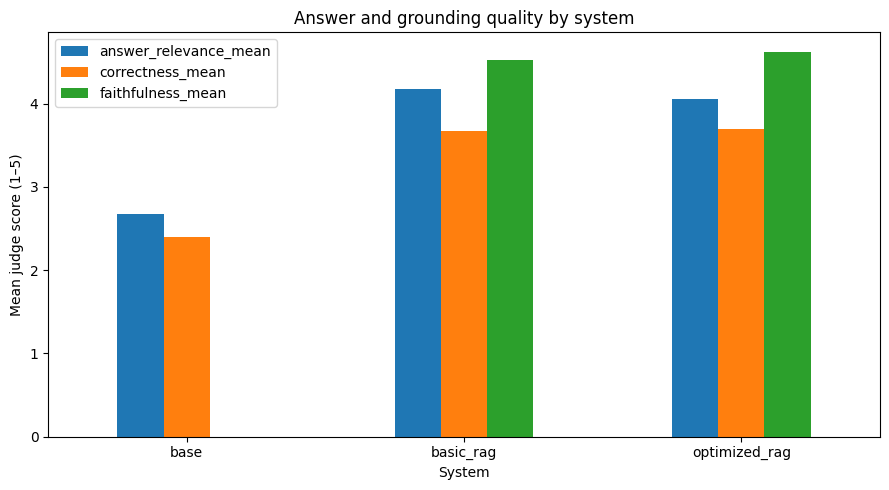

In [34]:
plot_frame = system_summary_df.set_index('system')

plt.figure(figsize=(9, 5))
plot_frame[
    ['answer_relevance_mean', 'correctness_mean', 'faithfulness_mean']
].plot(kind='bar', ax=plt.gca())
plt.title('Answer and grounding quality by system')
plt.ylabel('Mean judge score (1–5)')
plt.xlabel('System')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

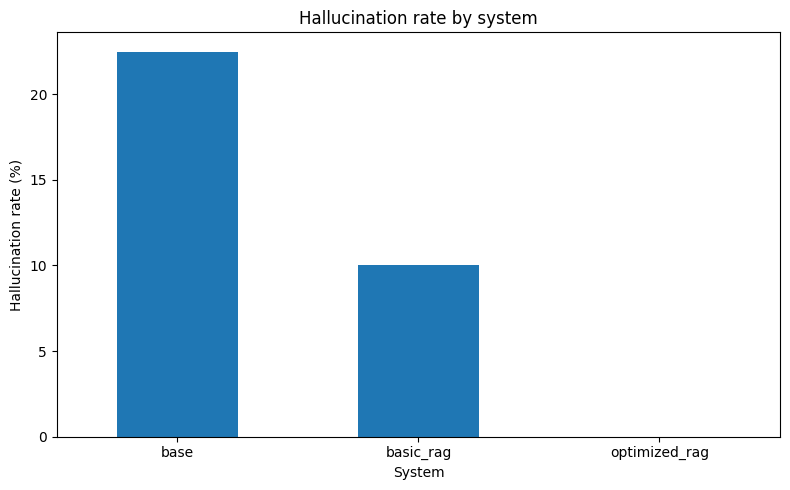

In [35]:
plt.figure(figsize=(8, 5))
plot_frame['hallucination_rate_pct'].plot(kind='bar', ax=plt.gca())
plt.title('Hallucination rate by system')
plt.ylabel('Hallucination rate (%)')
plt.xlabel('System')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

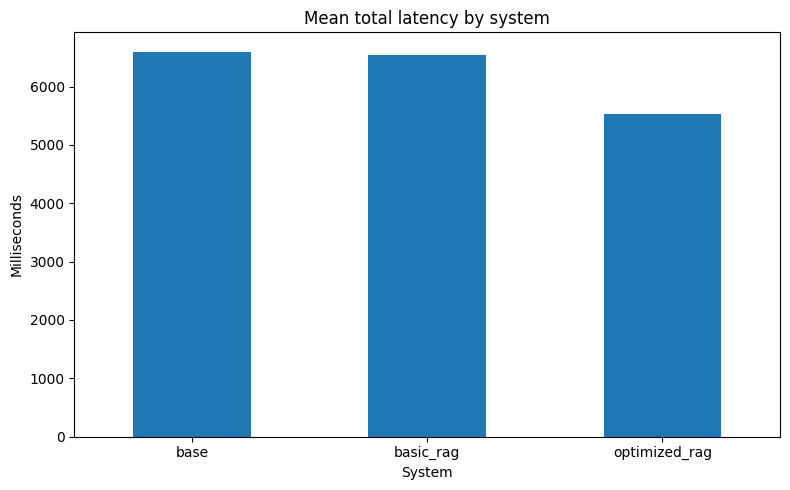

In [36]:
plt.figure(figsize=(8, 5))
plot_frame['total_latency_ms_mean'].plot(kind='bar', ax=plt.gca())
plt.title('Mean total latency by system')
plt.ylabel('Milliseconds')
plt.xlabel('System')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Generate the comparative Markdown report

In [37]:
winner_counts = judged_df['judge_winner'].fillna('unknown').value_counts().to_dict()

report_lines = [
    '# Agriculture RAG Benchmark Report',
    '',
    f'Generated: {datetime.now().isoformat()}',
    '',
    '## Evaluation design',
    '',
    f'- Gold questions: {len(judged_df)}',
    '- Systems: Base LLM, Basic RAG, Optimized Routed RAG',
    '- Catalog questions use exact expected item IDs.',
    '- Chat questions come from held-out conversations excluded from Chroma.',
    '- Edge cases test clarification and no-retrieval behavior.',
    '',
    '## Overall results',
    '',
    system_summary_df.round(3).to_markdown(index=False),
    '',
    '## Retrieval results',
    '',
    retrieval_summary_df.round(3).to_markdown(index=False),
    '',
    '## Winner counts',
    '',
    json.dumps(winner_counts, indent=2),
    '',
    '## Paired bootstrap comparison: Optimized RAG minus Base',
    '',
    comparison_df.round(3).to_markdown(index=False),
    '',
    '## Interpretation guide',
    '',
    '- Compare correctness, relevance, hallucination, and safety first.',
    '- Compare Basic RAG with Optimized RAG to isolate routing and reranking value.',
    '- Use retrieval metrics to explain why answer quality changed.',
    '- Use latency and token totals to describe the quality/cost trade-off.',
    '',
    '## Human-review requirement',
    '',
    'The held-out chat gold items must be manually reviewed before final submission.',
]

REPORT_PATH.write_text('\n'.join(report_lines), encoding='utf-8')
print('Saved report:', REPORT_PATH)

Saved report: /content/drive/MyDrive/Agriculture_version_2/evaluation/step3_benchmark_report.md


## 20. Step 3 completion checks

In [38]:
required_categories = {
    'dosage', 'ingredient', 'crop_compatibility', 'product_usage',
    'safety', 'diagnosis', 'after_sales', 'clarification',
}

completion_checks = {
    'gold_size_between_30_and_50': 30 <= len(gold_df) <= 50,
    'gold_size_matches_target': len(gold_df) == EXPECTED_GOLD_SIZE,
    'catalog_gold_present': gold_df['gold_origin'].eq('catalog').sum() == 20,
    'chat_holdout_gold_present': gold_df['gold_origin'].eq('chat_holdout').sum() == 16,
    'edge_gold_present': gold_df['gold_origin'].eq('edge_case').sum() == 4,
    'required_categories_present': required_categories <= set(gold_df['category']),
    'no_holdout_leakage': len(chat_gold_holdout_ids & indexed_chat_ids) == 0,
    'all_three_systems_completed': judged_df[
        ['base_error', 'basic_rag_error', 'optimized_rag_error']
    ].fillna('').eq('').all().all(),
    'judge_completed': judged_df['judge_error'].fillna('').eq('').all(),
    'catalog_retrieval_metrics_created': not retrieval_summary_df.empty,
    'system_summary_created': not system_summary_df.empty,
    'category_summary_created': not category_summary_df.empty,
    'report_saved': REPORT_PATH.exists(),
    'output_files_saved': all(path.exists() for path in [
        GOLD_CSV_PATH,
        GOLD_JSONL_PATH,
        RAW_RESULTS_CSV_PATH,
        JUDGED_RESULTS_PATH,
        SYSTEM_SUMMARY_PATH,
        CATEGORY_SUMMARY_PATH,
        RETRIEVAL_SUMMARY_PATH,
        BOOTSTRAP_PATH,
    ]),
}

print('STEP 3 COMPLETION CHECKS')
print('=' * 78)
for name, passed in completion_checks.items():
    print(f"{'PASS' if passed else 'FAIL'} - {name}")

manual_review_remaining = int(
    gold_df['review_status'].eq('needs_human_review').sum()
)
print('\nHeld-out gold rows still marked for human review:', manual_review_remaining)

if all(completion_checks.values()):
    print(
        '\nStep 3 is technically complete. Complete the documented human review '
        'before final submission.'
    )
else:
    print('\nResolve failed checks before writing the final benchmark conclusion.')

STEP 3 COMPLETION CHECKS
PASS - gold_size_between_30_and_50
PASS - gold_size_matches_target
PASS - catalog_gold_present
PASS - chat_holdout_gold_present
PASS - edge_gold_present
PASS - required_categories_present
PASS - no_holdout_leakage
PASS - all_three_systems_completed
PASS - judge_completed
PASS - catalog_retrieval_metrics_created
PASS - system_summary_created
PASS - category_summary_created
PASS - report_saved
PASS - output_files_saved

Held-out gold rows still marked for human review: 0

Step 3 is technically complete. Complete the documented human review before final submission.


## Main outputs

- `evaluation_gold_40.csv`
- `evaluation_gold_40.jsonl`
- `evaluation_gold_review.csv`
- `step3_raw_benchmark_results.csv`
- `step3_raw_benchmark_results.jsonl`
- `step3_judged_results.csv`
- `step3_system_summary.csv`
- `step3_category_summary.csv`
- `step3_retrieval_summary.csv`
- `step3_bootstrap_comparison.csv`
- `evaluation/step3_benchmark_report.md`

These outputs cover the project requirements for a golden evaluation dataset, Base versus RAG benchmarking, retrieval and grounding metrics, hallucination analysis, latency/token trade-offs, and a comparative report.